L'idée est de tester si la simple représentation sous forme de graphe avec une fonction de coût adaptée fournit les mêmes résultats pour le transport, que ceux obtenus en utilisant les *embeddings*. Cela permet de valider ou pas la pertinence d'une telle approche.

## Imports

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from collections import defaultdict
from poincare import PoincareManifold
from model import Distance_PE
from data_utils import *
from OT_utils import *
from information_content import *
from data import *
from evaluation import *

/home/onyxia/work/OT_simulation_maladies/Embeddings/data.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


ncbi_gene_id              str
gene_symbol               str
association_type          str
disease_id                str
#string_protein_id        str
annotation                str
protein2                  str
combined_score        float64
dtype: object

1
2
3


In [2]:
# Les 7 sous ontologies
inheritance = nx.ancestors(G_hpo_work, 'HP:0000005')
onset = nx.ancestors(G_hpo_work, 'HP:0012823')
abnormality = nx.ancestors(G_hpo_work, 'HP:0000118')
history = nx.ancestors(G_hpo_work, 'HP:0032443')
biospecimen = nx.ancestors(G_hpo_work, 'HP:0020228')
blood = nx.ancestors(G_hpo_work, 'HP:0032223')
frequency = nx.ancestors(G_hpo_work, 'HP:0040279')
categories = {
    'inheritance': list(inheritance), 
    'onset' : list(onset), 
    'abnormality' : list(abnormality), 
    'history' : list(history), 
    'biospecimen' : list(biospecimen),
    'blood' : list(blood), 
    'frequency' : list(frequency)}

In [3]:
# Seuils calcul de la courbe PR
seuils = np.linspace(0, 1., 30)

# Valeurs de tau à tester
taus = [0., 0.5, 0.7, 0.8, 0.9, 0.95, 1.]

## Utilisation de la table de correspondances d'Orphadata

### Chargement des données

In [ ]:
# Bases de d'annotations binaires
work_omim = work_omim.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orpha = work_orpha.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
hpo_cols0 = [c for c in work_omim.columns if c.startswith("HP:")]
# Certaines maladies ne sont encodées que sur les autres sous ontologies
work_omim = work_omim[(work_omim[hpo_cols0].sum(axis=1) != 0)] 
work_orpha = work_orpha[(work_orpha[hpo_cols0].sum(axis=1) != 0)]

df_orpha_omim_exact = df_orpha_omim[df_orpha_omim["mapping_type"]=='E (Exact mapping: the two concepts are equivalent)']
gt_set, valid_omim, valid_orpha = f_ground_truth(work_omim, work_orpha, df_orpha_omim_exact)
print(f"Taille OMIM : {work_omim.shape[0]}, ORPHA : {work_orpha.shape[0]}, paires GT : {len(gt_set)}")

Taille OMIM : 6686, ORPHA : 3189, paires GT : 2217


In [ ]:
# Données avec les fréquences des termes HPO 
work_omimF = work_omimF.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orphaF = work_orphaF.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)  # df_hpoa

work_omimF2 = work_omimF2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orphaF2 = work_orphaF2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)  # Orphadata

hpo_colsF = [c for c in work_omimF.columns if c.startswith("HP:")]
hpo_colsF2 = [c for c in work_omimF2.columns if c.startswith("HP:")]

work_omimF = work_omimF[(work_omimF[hpo_colsF].sum(axis=1) != 0)] 
work_orphaF = work_orphaF[(work_orphaF[hpo_colsF].sum(axis=1) != 0)]

work_omimF2 = work_omim[(work_omimF2[hpo_colsF2].sum(axis=1) != 0)] 
work_orphaF2 = work_orpha[(work_orphaF2[hpo_colsF2].sum(axis=1) != 0)]

gt_setF, valid_omimF, valid_orphaF = f_ground_truth(work_omimF, work_orphaF, df_orpha_omim_exact)
gt_setF2, valid_omimF2, valid_orphaF2 = f_ground_truth(work_omimF2, work_orphaF2, df_orpha_omim_exact)

print(f"Taille OMIM : {work_omimF.shape[0]}, ORPHA : {work_orphaF.shape[0]}, paires GT : {len(gt_setF)}")

Taille OMIM : 6686, ORPHA : 3189, paires GT : 2217


In [ ]:
# Avec les maladies Orpha directement tirées d'Orphadata
work_omim2 = work_omim2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orpha2 = work_orpha2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
hpo_cols2 = [c for c in work_omim2.columns if c.startswith("HP:")]
# Certaines maladies ne sont encodées que sur les autres sous ontologies
work_omim2 = work_omim2[(work_omim2[hpo_cols2].sum(axis=1) != 0)] 
work_orpha2 = work_orpha2[(work_orpha2[hpo_cols2].sum(axis=1) != 0)]

gt_set2, valid_omim2, valid_orpha2 = f_ground_truth(work_omim2, work_orpha2, df_orpha_omim_exact)
print(f"Taille OMIM : {work_omim2.shape}, ORPHA : {work_orpha2.shape}, paires GT : {len(gt_set2)}")

Taille OMIM : (6686, 11559), ORPHA : (3211, 11559), paires GT : 2237


In [7]:
# Bases de données propagées
import tsw
ancestors = {hp: get_ancestors0(G_hpo_work, hp) for hp in hpo_cols0}
w_omim_P = tsw.propagate_terms(work_omim,  hpo_cols0, ancestors, depths, k=3)
w_orpha_P = tsw.propagate_terms(work_orpha, hpo_cols0, ancestors, depths, k=3)

w_omim_P2 = tsw.propagate_terms(work_omim2,  hpo_cols2, ancestors, depths, k=3)
w_orpha_P2 = tsw.propagate_terms(work_orpha2, hpo_cols2, ancestors, depths, k=3)

w_omim_PF2 = tsw.propagate_terms(work_omimF2, hpo_colsF2, ancestors, depths, k=3)
w_orpha_PF2 = tsw.propagate_terms(work_orphaF2, hpo_colsF2, ancestors, depths, k=3)

In [ ]:
# Ground truth incluant toutes les associations
gt_set_broad, _, _= f_ground_truth(work_omim, work_orpha, df_orpha_omim)
i_set = [a for a, b in gt_set]
d_gt = defaultdict(list)  # Dictionnaire {Maladie OMIM : [Maladie(s) Orphanet]}
for i, j in gt_set_broad:
    if np.isin(i, i_set):
        d_gt[i].append(j)

### Distances simples : Jaccard, Hamming

In [ ]:
# Dictionnaire pour stocker les résultats méthode par méthode
dict_method={}

# Distances de base
for dist_method in ['jaccard', 'hamming']:
    print(dist_method)
    C = basic_cost_matrix(w_omim_P2, w_orpha_P2, dist_method)

    # Sans régularisation
    print("======== Sans régularisation ========")
    ot_plan, ot_cost = compute_transport(C, a=None, b=None)
    ranks, _, pairs, _, _ = evaluate_transport(ot_plan, gt_set2, C)

    # Avec régularisation
    print("======== Avec régularisation ========")
    grid = np.linspace(0.01, 5, 100)
    epsilon = grid[1] * np.mean(C)
    print(epsilon)
    ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
    ranks_reg, ranks_reg2, pairs_reg, pairs_reg2, _ = evaluate_transport(ot_plan_reg, gt_set2, C)
    print()
    dict_method[f"{dist_method} reg"] = {
        "cost_matrix": C,
        "ot_plan":ot_plan_reg}
    save_method(dict)

jaccard
Check : (6686, 3211)
======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.596 (1333/2237)
Top-3 accuracy : 0.627 (1403/2237)
Top-5 accuracy : 0.629 (1408/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.394 (882/2237)
Top-3 accuracy : 0.626 (1400/2237)
Top-5 accuracy : 0.629 (1406/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.394 (882/2237)
Top-3 accuracy : 0.625 (1398/2237)
Top-5 accuracy : 0.629 (1406/2237)
 Rang moyen des maladies Orpha : 604.30
 Rang moyen des maladies Omim : 936.08
======== Avec régularisation ========
0.05726064769908636
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.583 (1304/2237)
Top-3 accuracy : 0.717 (1604/2237)
Top-5 accuracy : 0.776 (1735/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.555 (1242/2237)
Top-3 accuracy : 0.677 (1514/2237)
Top-5 accuracy : 0.722 (1616/2237)
=========== Lignes et Colonnes ===========
Top-1 accurac

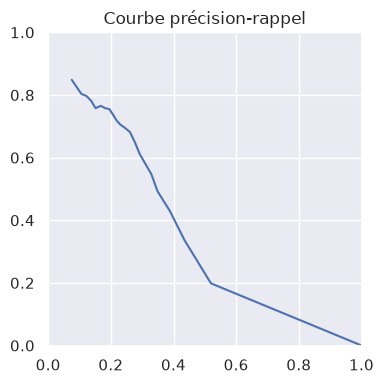

In [ ]:
plot_PR_curve(ot_plan_reg, gt_set2, seuils)

jaccard
Check : (6686, 3211)
0.057260650075760026


100%|██████████| 3/3 [01:26<00:00, 28.76s/it]


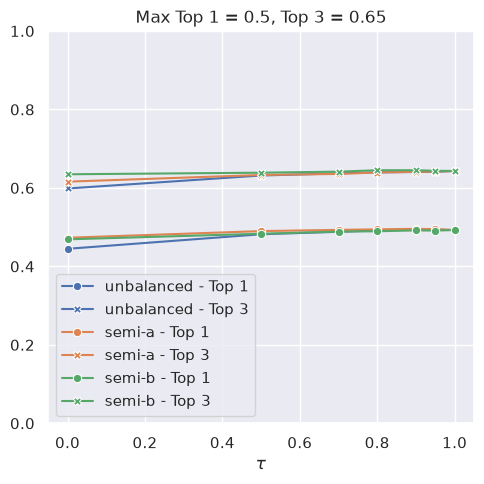

hamming
Check : (6686, 3211)
8.547288928112646


100%|██████████| 3/3 [01:49<00:00, 36.57s/it]


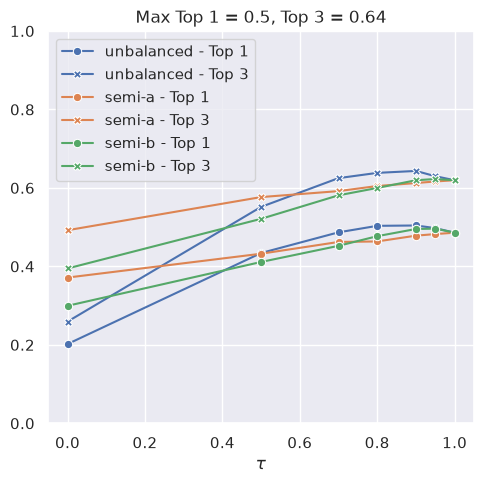

In [ ]:
dist_methods = ['jaccard', 'hamming']
for dist_method in dist_methods:
    print(dist_method)
    C = basic_cost_matrix(w_omim_P2, w_orpha_P2, dist_method)
    grid = np.linspace(0.01, 5, 100)
    epsilon = grid[1] * np.mean(C)
    print(epsilon)
    plot_unbalanced(taus, C, epsilon, gt_set2)

Train : 1789
 Test : 448
Accuracy : 0.741
Precision: 0.785
Recall   : 0.741
ROC-AUC : 0.844
PR-AUC : 0.909


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


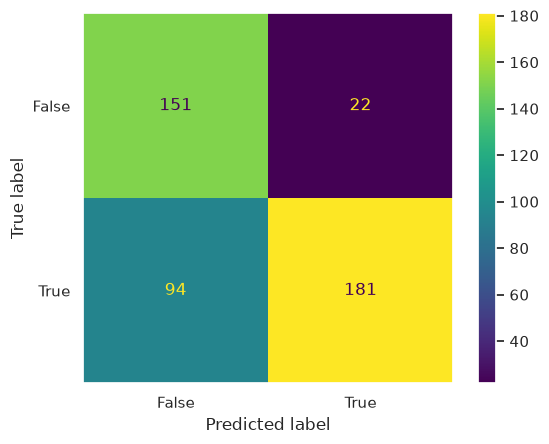

top_1       4.066200
sds        -3.905067
ratio_12    2.639842
dtype: float64
Seuil pour 90.0% précision : 0.524 (recall correspondant : 0.633)


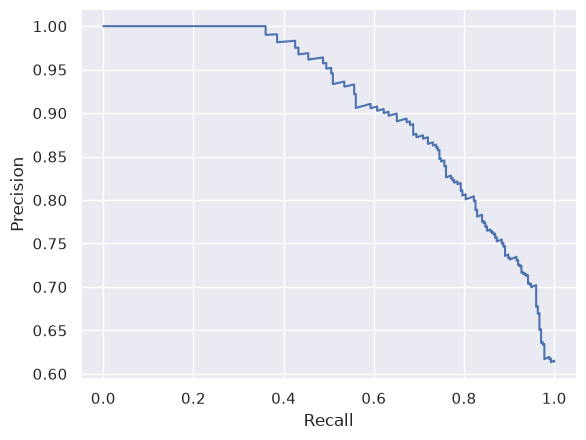

/home/onyxia/work/OT_simulation_maladies/Embeddings/evaluation.py:199: RuntimeWarning: invalid value encountered in divide
  C = (X @ Y.T)/np.sum(X, axis=1, keepdims=True)  # Part de termes en communs par rapport à OMIM


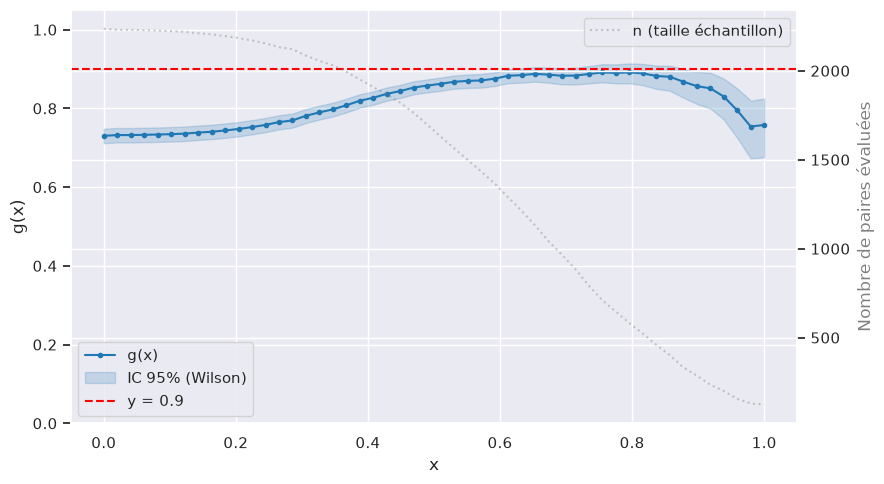

In [9]:
logistic_reg(dict_method['hamming reg']['ot_plan'], gt_set2)
x, g = seuil_commun(w_omim_P2, w_orpha_P2, dict_method['hamming reg']['ot_plan'], gt_set2, alpha=0.9)

### Distance euclidienne calculée à partir des prévalences

In [ ]:
C = basic_cost_matrix(work_omimF2, work_orphaF2, 'euclidean')

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, _, pairs, _, _ = evaluate_transport(ot_plan, gt_setF2, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = evaluate_transport(ot_plan_reg, gt_setF2, C)

Check : (6686, 3211)
======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.184 (412/2237)
Top-3 accuracy : 0.203 (453/2237)
Top-5 accuracy : 0.203 (455/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.110 (246/2237)
Top-3 accuracy : 0.202 (451/2237)
Top-5 accuracy : 0.202 (452/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.110 (246/2237)
Top-3 accuracy : 0.201 (450/2237)
Top-5 accuracy : 0.202 (452/2237)
 Rang moyen des maladies Orpha : 1287.27
 Rang moyen des maladies Omim : 2019.47
======== Avec régularisation ========
0.18266415090488683
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.175 (391/2237)
Top-3 accuracy : 0.242 (542/2237)
Top-5 accuracy : 0.277 (619/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.190 (424/2237)
Top-3 accuracy : 0.251 (562/2237)
Top-5 accuracy : 0.287 (643/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.135 (301/2237

### Distances pondérées en exploitant juste la structure d'arbre 

#### Par les profondeurs

In [ ]:
C1 = cost_matrix_hamm(w_omim_P2, w_orpha_P2, depths)
print(np.isnan(C1).sum(), np.isinf(C1).sum())

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks,_, pairs,_, _ = evaluate_transport(ot_plan, gt_set2, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, ranks_reg2, pairs_reg, pairs_reg2, _ = evaluate_transport(ot_plan_reg, gt_set2, C1)
dict_method["profondeur reg"]={
                        "cost_matrix": C1,
                        "ot_plan": ot_plan_reg}
saave_method(dict_method, "profondeur reg")

0 0
======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.589 (1317/2237)
Top-3 accuracy : 0.617 (1381/2237)
Top-5 accuracy : 0.619 (1384/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.397 (887/2237)
Top-3 accuracy : 0.618 (1382/2237)
Top-5 accuracy : 0.618 (1383/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.397 (887/2237)
Top-3 accuracy : 0.617 (1380/2237)
Top-5 accuracy : 0.618 (1383/2237)
 Rang moyen des maladies Orpha : 620.16
 Rang moyen des maladies Omim : 951.01
======== Avec régularisation ========
46.669587812690764
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.613 (1371/2237)
Top-3 accuracy : 0.737 (1649/2237)
Top-5 accuracy : 0.786 (1759/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.552 (1235/2237)
Top-3 accuracy : 0.664 (1486/2237)
Top-5 accuracy : 0.707 (1581/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.477 (1067/2237)
Top-

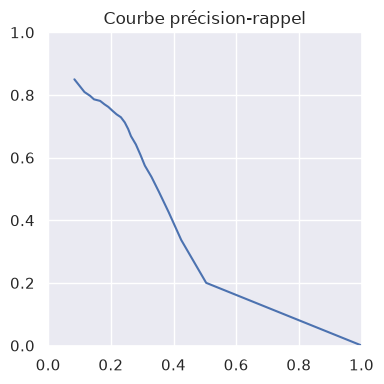

In [11]:
plot_PR_curve(ot_plan_reg, gt_set2, seuils)

100%|██████████| 3/3 [02:03<00:00, 41.02s/it]


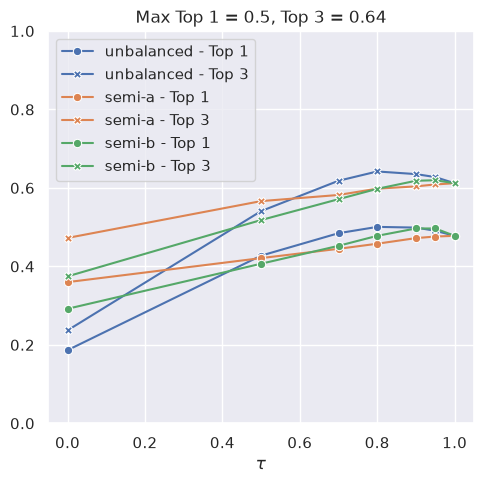

In [ ]:
plot_unbalanced(taus, C1, epsilon, gt_set2)

#### Par l'*information content*

In [9]:
union_diseases = add_corresponding_terms(work_omim2, work_orpha2, df_orpha_omim_exact)
remaining_orpha = work_orpha2[~work_orpha2['database_id'].isin(valid_orpha2)]
print(union_diseases.shape, remaining_orpha.shape)
all_diseases = pd.concat([union_diseases, remaining_orpha])
weights_all,_, _ = compute_information_content(all_diseases, G_hpo_work)
weights_all = {t:-np.log(w) for t, w in weights_all.items()}

Fusion HPO: 100%|██████████| 2237/2237 [00:00<00:00, 10061.34it/s]


(6686, 11559) (974, 11559)


In [ ]:
C1 = cost_matrix_hamm(w_omim_P2, w_orpha_P2, weights_all)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks, _, pairs, _, _ = evaluate_transport(ot_plan, gt_set2, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, ranks_reg2, pairs_reg, pairs_reg2, _ = evaluate_transport(ot_plan_reg, gt_set2, C1)

dict_method["ic"]={"ot_plan": ot_plan_reg,
                    "cost_matrix": C1}
save_method(dict_method, "ic")

======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.605 (1353/2237)
Top-3 accuracy : 0.638 (1428/2237)
Top-5 accuracy : 0.640 (1431/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.405 (907/2237)
Top-3 accuracy : 0.637 (1426/2237)
Top-5 accuracy : 0.639 (1429/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.405 (907/2237)
Top-3 accuracy : 0.637 (1424/2237)
Top-5 accuracy : 0.639 (1429/2237)
 Rang moyen des maladies Orpha : 588.14
 Rang moyen des maladies Omim : 891.45
======== Avec régularisation ========
69.34124500195348
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.629 (1408/2237)
Top-3 accuracy : 0.745 (1666/2237)
Top-5 accuracy : 0.791 (1769/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.571 (1278/2237)
Top-3 accuracy : 0.679 (1518/2237)
Top-5 accuracy : 0.723 (1617/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.498 (1115/2237)
Top-3 acc

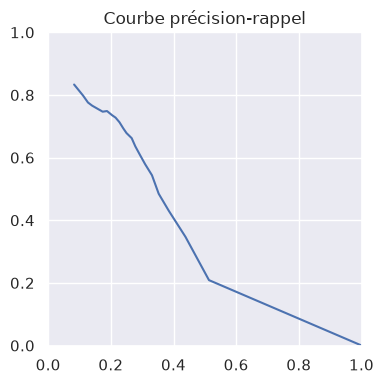

In [15]:
plot_PR_curve(ot_plan_reg, gt_set2, seuils)

100%|██████████| 3/3 [01:57<00:00, 39.30s/it]


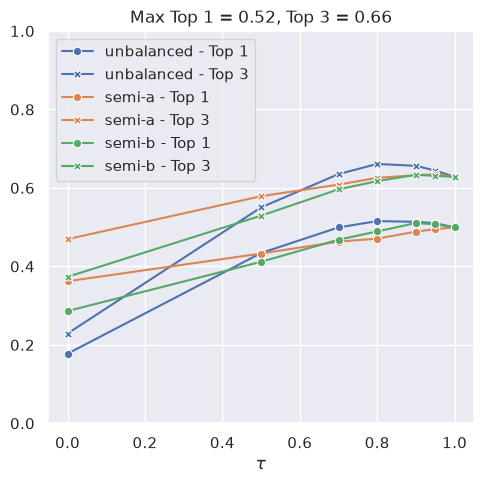

In [ ]:
plot_unbalanced(taus, C1, epsilon, gt_set2)

In [7]:
union_diseasesF = add_corresponding_terms(work_omimF2, work_orphaF2, df_orpha_omim_exact)
remaining_orphaF = work_orphaF2[~work_orphaF2['database_id'].isin(valid_orphaF2)]
print(union_diseasesF.shape, remaining_orphaF.shape)
all_diseasesF = pd.concat([union_diseasesF, remaining_orphaF])
weights_allF, _, _ = compute_information_content(all_diseasesF, G_hpo_work)
weights_allF = {t:-np.log(w) for t, w in weights_allF.items()}

Fusion HPO: 100%|██████████| 2237/2237 [00:00<00:00, 8253.68it/s]


(6686, 11559) (974, 11559)


In [ ]:
# Calcul de l'IC à partir des fréquences
C1 = cost_matrix_hamm(w_omim_P2, w_orpha_P2, weights_allF)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks, _, pairs, _, _ = evaluate_transport(ot_plan, gt_set2, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = evaluate_transport(ot_plan_reg, gt_set2, C1)

======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.595 (1330/2237)
Top-3 accuracy : 0.633 (1416/2237)
Top-5 accuracy : 0.634 (1418/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.396 (885/2237)
Top-3 accuracy : 0.631 (1412/2237)
Top-5 accuracy : 0.633 (1416/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.396 (885/2237)
Top-3 accuracy : 0.631 (1411/2237)
Top-5 accuracy : 0.633 (1416/2237)
 Rang moyen des maladies Orpha : 599.84
 Rang moyen des maladies Omim : 908.13
======== Avec régularisation ========
68.97251000213288
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.628 (1404/2237)
Top-3 accuracy : 0.741 (1658/2237)
Top-5 accuracy : 0.787 (1760/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.563 (1259/2237)
Top-3 accuracy : 0.671 (1500/2237)
Top-5 accuracy : 0.713 (1596/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.495 (1108/2237)
Top-3 acc

Train : 1789
 Test : 448
Accuracy : 0.768
Precision: 0.822
Recall   : 0.768
ROC-AUC : 0.861
PR-AUC : 0.921


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


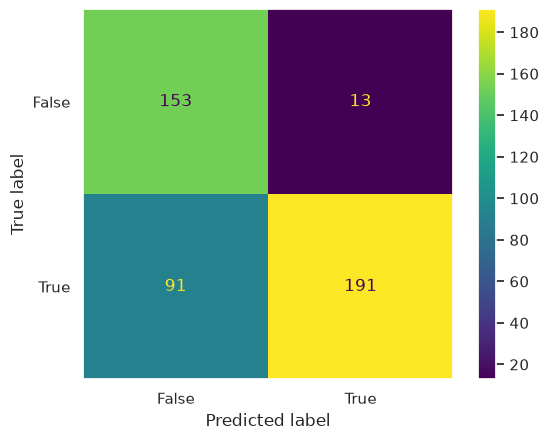

top_1       3.750185
sds        -3.698662
ratio_12    2.898732
dtype: float64
Seuil pour 90.0% précision : 0.428 (recall correspondant : 0.727)


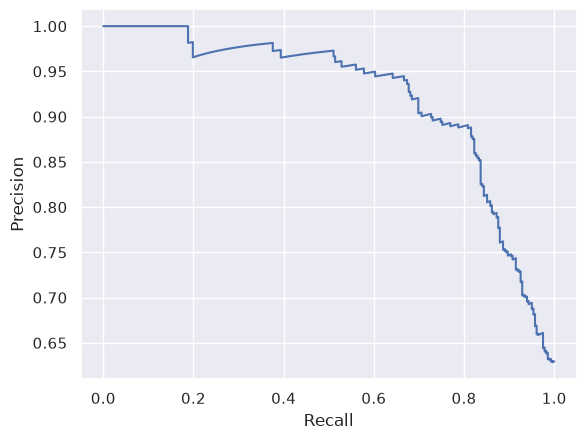

/home/onyxia/work/OT_simulation_maladies/Embeddings/evaluation.py:199: RuntimeWarning: invalid value encountered in divide
  C = (X @ Y.T)/np.sum(X, axis=1, keepdims=True)  # Part de termes en communs par rapport à OMIM


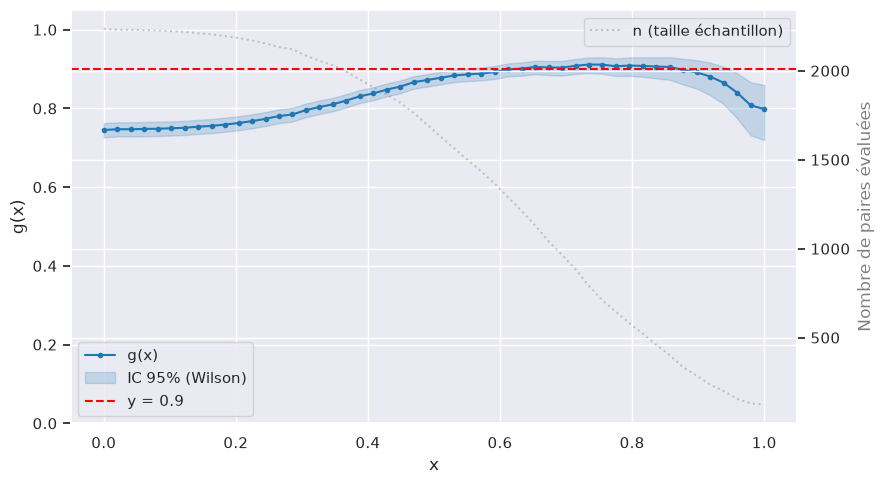

Pourcentage de termes partagés min : 63.0%
Pourcentage de termes partagés max : 86.0%


In [17]:
metrics, X_train, X_test, y_train, y_test, model = logistic_reg(dict_method['ic']['ot_plan'], gt_set2)
x, y = seuil_commun(w_omim_P2, w_orpha_P2, dict_method['ic']['ot_plan'], gt_set2, alpha=0.9)
print(f"Pourcentage de termes partagés min : {np.round(x[np.where(np.array(y)>0.9)[0][0]]*100)}%")
print(f"Pourcentage de termes partagés max : {np.round(x[np.where(np.array(y)>0.9)[0][-1]]*100)}%")

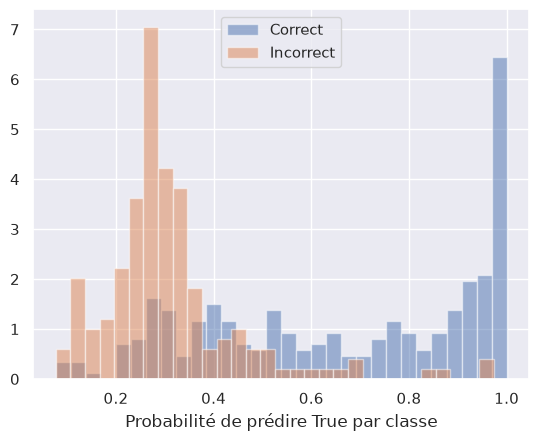

In [18]:
proba_test = model.predict_proba(X_test)[:, 1]
plt.hist(proba_test[y_test==np.True_], bins=30, alpha=0.5, label='Correct', density=True)
plt.hist(proba_test[y_test==np.False_], bins=30, alpha=0.5, label='Incorrect', density=True)
plt.xlabel("Probabilité de prédire True par classe")
plt.legend()

In [ ]:
not_min=defaultdict(set)
for (i, j_true) in gt_set:
    j_pred = np.argmin(C1[i])
    if j_pred != j_true:
        not_min[(i,j_true)].add(j_pred)
        # print(f"C[i, j_true]={C1[i,j_true]:.3f}, C[i, j_pred]={C1[i,j_pred]:.3f}")
print(f"{len(not_min)}/{len(gt_set)} soit {np.round(len(not_min)/len(gt_set), 2)*100}% des prédictions ne correspondent pas au coût minimum pour la ligne.")

2035/2217 soit 92.0% des prédictions ne correspondent pas au coût minimum pour la ligne


### Composition des distances de Jaccard et IC

In [ ]:
C_jacc = dict_method["jaccard reg"]["cost_matrix"]
C1_max = np.max(C1, axis=1, keepdims=True)
C1 = C1/C1_max
for a in [0.2, 0.4, 0.6, 0.8]:
    print("="*40)
    print(f"a = {a}")
    C_comp = a*C1 + (1-a)*C_jacc
    print("======== Sans régularisation ========")
    ot_plan, ot_cost = compute_transport(C_comp, a=None, b=None)
    ranks, _, pairs, _, _ = evaluate_transport(ot_plan, gt_set, C_comp)

    # Avec régularisation
    print("======== Avec régularisation ========")
    grid = np.linspace(0.01, 5, 100)
    epsilon = grid[1] * np.mean(C_comp)
    print(epsilon)
    ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_comp, None, None, epsilon, 10000, 1e-4, False)
    ranks_reg, _, pairs_reg, _, _ = evaluate_transport(ot_plan_reg, gt_set, C_comp)
    

a = 0.2
======== Sans régularisation ========


Paires évaluées : 2217
Top-1 accuracy : 0.599 (1327/2217)
Top-3 accuracy : 0.625 (1386/2217)
Top-5 accuracy : 0.627 (1389/2217)
 Rang moyen: 604.22
======== Avec régularisation ========
0.04888787169153508
Paires évaluées : 2217
Top-1 accuracy : 0.585 (1298/2217)
Top-3 accuracy : 0.722 (1601/2217)
Top-5 accuracy : 0.774 (1715/2217)
 Rang moyen: 28.09
a = 0.4
======== Sans régularisation ========
Paires évaluées : 2217
Top-1 accuracy : 0.603 (1336/2217)
Top-3 accuracy : 0.629 (1394/2217)
Top-5 accuracy : 0.631 (1398/2217)
 Rang moyen: 597.35
======== Avec régularisation ========
0.04051826965654181
Paires évaluées : 2217
Top-1 accuracy : 0.590 (1308/2217)
Top-3 accuracy : 0.728 (1615/2217)
Top-5 accuracy : 0.777 (1723/2217)
 Rang moyen: 26.55
a = 0.6
======== Sans régularisation ========
Paires évaluées : 2217
Top-1 accuracy : 0.604 (1339/2217)
Top-3 accuracy : 0.630 (1396/2217)
Top-5 accuracy : 0.632 (1401/2217)
 Rang moyen: 595.85
======== Avec régularisation ========
0.03214866762154

### Distances qui exploitent l'*embedding*

In [19]:
checkpoint = torch.load('logs/2026_5_7/12/model_final.pt', map_location='cpu', weights_only=False)
hp = checkpoint['hyperparams']
objects = checkpoint['objects']
manifold = PoincareManifold()
model = Distance_PE(n=len(objects), dim=hp['dim'],
                       manifold=manifold, sparse=False, learn_curvature=False, init_curvature=1., weight_decay=0)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


Distance_PE(
  (embeddings): Embedding(19389, 15)
)

In [ ]:
C_mod = compute_cost_matrix_pseudo_jacc(w_omim_P2, w_orpha_P2, node2id_w, model)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_mod, a=None, b=None)
ranks, _, pairs, _, _ = evaluate_transport(ot_plan, gt_set2, C_mod)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_mod)
print(epsilon)
ot_plan_reg, ot_cost_reg = compute_transport_sinkhorn(C_mod, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = evaluate_transport(ot_plan_reg, gt_set2, C_mod)
dict_method["embedding_hamming"]={
                    "ot_plan": ot_plan_reg,
                    "cost_matrix": C_mod}
save_method(dict_method, "embedding_hamming")

Compute norms
Norms computed !
======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.598 (1337/2237)
Top-3 accuracy : 0.631 (1412/2237)
Top-5 accuracy : 0.633 (1417/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.405 (907/2237)
Top-3 accuracy : 0.631 (1411/2237)
Top-5 accuracy : 0.633 (1415/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.405 (907/2237)
Top-3 accuracy : 0.630 (1409/2237)
Top-5 accuracy : 0.633 (1415/2237)
 Rang moyen des maladies Orpha : 591.65
 Rang moyen des maladies Omim : 912.84
======== Avec régularisation ========
27.35124318891458
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.624 (1395/2237)
Top-3 accuracy : 0.749 (1676/2237)
Top-5 accuracy : 0.793 (1774/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.570 (1274/2237)
Top-3 accuracy : 0.675 (1511/2237)
Top-5 accuracy : 0.724 (1619/2237)
=========== Lignes et Colonnes ===========
Top-1 accurac

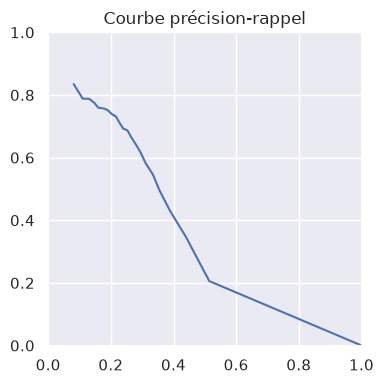

In [21]:
plot_PR_curve(ot_plan_reg, gt_set2, seuils)

100%|██████████| 3/3 [01:56<00:00, 38.87s/it]


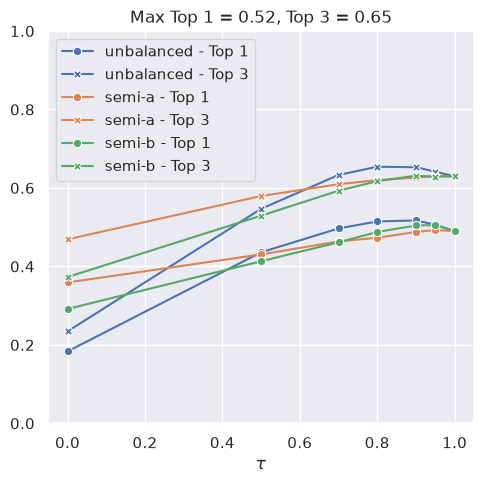

In [16]:
taus = [0., 0.5, 0.7, 0.8, 0.9, 0.95, 1.]
plot_unbalanced(taus, C_mod, epsilon, gt_set2)

In [ ]:
C_wass = compute_costs_matrix_wasserstein2(work_omim2, work_orpha2, node2id_w, model, deprecated)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_wass, a=None, b=None)
ranks, _, pairs, _, _ = evaluate_transport(ot_plan, gt_set2, C_wass)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_wass)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_wass, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = evaluate_transport(ot_plan_reg, gt_set2, C_wass)
dict_method["embedding_wasserstein"]={
                    "ot_plan": ot_plan_reg,
                    "cost_matrix": C_wass}
save_method(dict_method, "embedding_wasserstein")

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 42/42 [00:02<00:00, 14.70it/s]


HPO distance matrix: (10646, 10646)


OMIM: 100%|██████████| 6686/6686 [20:05<00:00,  5.55it/s]


======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.563 (1260/2237)
Top-3 accuracy : 0.599 (1340/2237)
Top-5 accuracy : 0.602 (1346/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.388 (867/2237)
Top-3 accuracy : 0.599 (1341/2237)
Top-5 accuracy : 0.601 (1344/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.388 (867/2237)
Top-3 accuracy : 0.598 (1338/2237)
Top-5 accuracy : 0.601 (1344/2237)
 Rang moyen des maladies Orpha : 643.82
 Rang moyen des maladies Omim : 997.74
======== Avec régularisation ========
0.4067933351762566
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.557 (1246/2237)
Top-3 accuracy : 0.710 (1588/2237)
Top-5 accuracy : 0.762 (1705/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.536 (1199/2237)
Top-3 accuracy : 0.664 (1486/2237)
Top-5 accuracy : 0.709 (1586/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.471 (1053/2237)
Top-3 ac

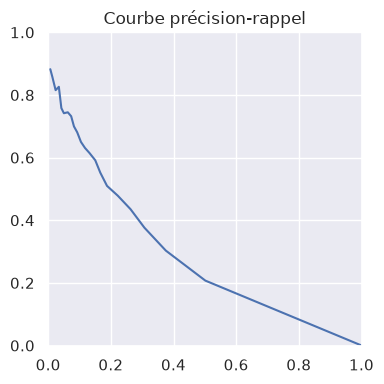

In [23]:
plot_PR_curve(ot_plan_reg, gt_set2, seuils)

100%|██████████| 3/3 [01:20<00:00, 26.85s/it]


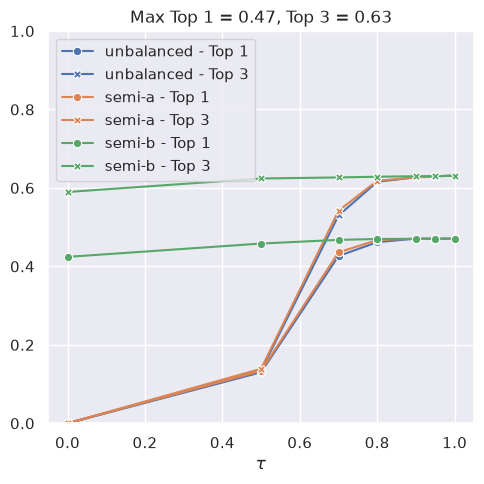

In [ ]:
plot_unbalanced(taus, C_wass, epsilon, gt_set2)

In [ ]:
C_wass = compute_costs_matrix_wasserstein2(work_omimF2, work_orphaF2, node2id_w, model, deprecated)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_wass, a=None, b=None)
ranks, _, pairs, _, _ = evaluate_transport(ot_plan, gt_setF2, C_wass)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_wass)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_wass, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = evaluate_transport(ot_plan_reg, gt_setF2, C_wass)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 38/38 [00:01<00:00, 22.56it/s]


HPO distance matrix: (9477, 9477)


OMIM: 100%|██████████| 6686/6686 [26:21<00:00,  4.23it/s]


======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.269 (602/2237)
Top-3 accuracy : 0.285 (637/2237)
Top-5 accuracy : 0.287 (641/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.175 (392/2237)
Top-3 accuracy : 0.285 (637/2237)
Top-5 accuracy : 0.285 (637/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.175 (392/2237)
Top-3 accuracy : 0.284 (636/2237)
Top-5 accuracy : 0.285 (637/2237)
 Rang moyen des maladies Orpha : 1134.13
 Rang moyen des maladies Omim : 1754.25
======== Avec régularisation ========
0.30765723992228405
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.278 (621/2237)
Top-3 accuracy : 0.356 (796/2237)
Top-5 accuracy : 0.395 (883/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.273 (610/2237)
Top-3 accuracy : 0.349 (780/2237)
Top-5 accuracy : 0.378 (846/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.232 (518/2237)
Top-3 accuracy : 0.

In [ ]:
# Comparaison entre min(C) et la vraie paire
not_min=defaultdict(set)
for (i, j_true) in gt_set:
    j_pred = np.argmin(C_wass[i])
    if j_pred != j_true:
        not_min[(i,j_true)].add(j_pred)
        # print(f"C[i, j_true]={C_wass[i,j_true]:.3f}, C[i, j_pred]={C_wass[i,j_pred]:.3f}")
print(f"{len(not_min)}/{len(gt_set)} soit {np.round(len(not_min)/len(gt_set), 2)*100}%")

3663/5312 soit 69.0%


### Distance s'appuyant sur les corrélations entre maladies

In [29]:
C_corr = correlation_cost(w_omim_P2, w_orpha_P2)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_corr, a=None, b=None)
ranks, _, pairs, _, _ = evaluate_transport(ot_plan, gt_set2, C_corr)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[2] * np.mean(C_corr)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_corr, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = evaluate_transport(ot_plan_reg, gt_set2, C_corr)
dict_method["correlation"]={
                    "ot_plan": ot_plan_reg,
                    "cost_matrix": C_corr}
save_method(dict_method, "correlation")

======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.624 (1395/2237)
Top-3 accuracy : 0.653 (1460/2237)
Top-5 accuracy : 0.655 (1465/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.416 (931/2237)
Top-3 accuracy : 0.654 (1462/2237)
Top-5 accuracy : 0.654 (1463/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.416 (931/2237)
Top-3 accuracy : 0.652 (1458/2237)
Top-5 accuracy : 0.654 (1463/2237)
 Rang moyen des maladies Orpha : 560.12
 Rang moyen des maladies Omim : 859.27
======== Avec régularisation ========
0.09964225048312753
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.601 (1344/2237)
Top-3 accuracy : 0.752 (1682/2237)
Top-5 accuracy : 0.798 (1786/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.568 (1271/2237)
Top-3 accuracy : 0.704 (1575/2237)
Top-5 accuracy : 0.746 (1669/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.496 (1110/2237)
Top-3 a

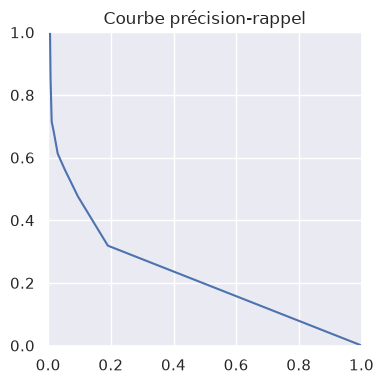

In [30]:
plot_PR_curve(ot_plan_reg, gt_set2, seuils)

100%|██████████| 3/3 [01:14<00:00, 24.99s/it]


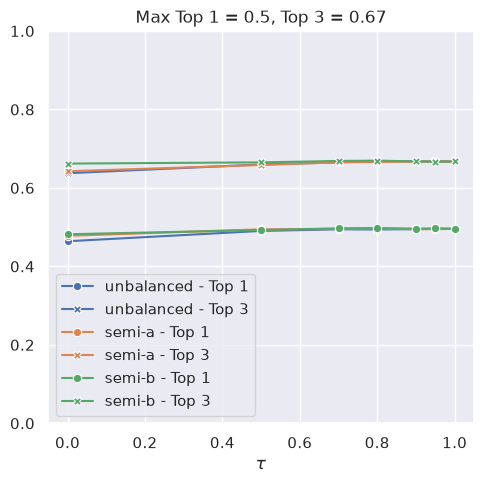

In [20]:
taus = [0., 0.5, 0.7, 0.8, 0.9, 0.95, 1.]
plot_unbalanced(taus, C_corr, epsilon, gt_set2)

### Distances s'appuyant sur la similarité de Resnik

A la vue des résultats, il est possible qu'il y ait une (ou des) erreur(s) dans le code. Cela semble difficile de bien calibrer la régularisation entropique dans ce cas.

In [10]:
# Calcul de la similarité entre chaque paire de termes HPO
print("Compute similarities...")
hpo_sim = resnik_similarity(all_diseases, G_hpo_work, weights_all)

Compute similarities...
Precomputing ancestors...
Finished !


11558it [02:05, 91.81it/s] 


======== max ========


100%|██████████| 3211/3211 [00:12<00:00, 265.24it/s]


======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.167 (374/2237)
Top-3 accuracy : 0.215 (481/2237)
Top-5 accuracy : 0.217 (485/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.093 (207/2237)
Top-3 accuracy : 0.213 (477/2237)
Top-5 accuracy : 0.215 (481/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.093 (207/2237)
Top-3 accuracy : 0.213 (476/2237)
Top-5 accuracy : 0.215 (481/2237)
 Rang moyen des maladies Orpha : 1283.38
 Rang moyen des maladies Omim : 2068.33
======== Avec régularisation ========
0.0027792821167060573


/opt/python/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:631: RuntimeWarning: overflow encountered in divide
  u = 1.0 / nx.dot(Kp, v)
/opt/python/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.169 (378/2237)
Top-3 accuracy : 0.304 (680/2237)
Top-5 accuracy : 0.383 (856/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.150 (335/2237)
Top-3 accuracy : 0.260 (582/2237)
Top-5 accuracy : 0.327 (732/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.100 (223/2237)
Top-3 accuracy : 0.203 (454/2237)
Top-5 accuracy : 0.274 (612/2237)
 Rang moyen des maladies Orpha : 68.86
 Rang moyen des maladies Omim : 136.60


  0%|          | 0/3 [00:00<?, ?it/s]/opt/python/lib/python3.13/site-packages/ot/unbalanced/_sinkhorn.py:757: RuntimeWarning: overflow encountered in divide
  u = (a / Kv) ** fi_1
/opt/python/lib/python3.13/site-packages/ot/unbalanced/_sinkhorn.py:770: UserWarning: Numerical errors at iteration 0
  warnings.warn("Numerical errors at iteration %s" % i)
100%|██████████| 3/3 [00:34<00:00, 11.41s/it]


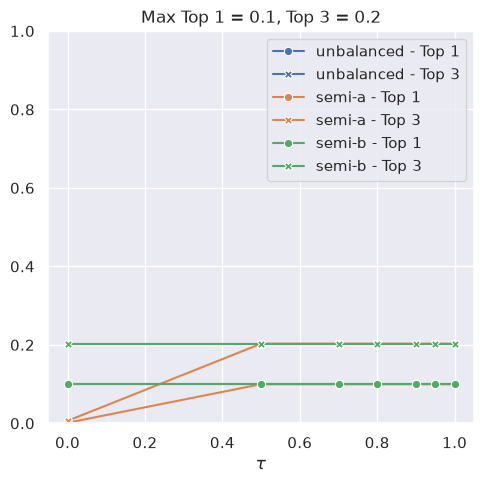


======== mean ========
======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.102 (229/2237)
Top-3 accuracy : 0.130 (291/2237)
Top-5 accuracy : 0.132 (296/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.058 (129/2237)
Top-3 accuracy : 0.129 (289/2237)
Top-5 accuracy : 0.131 (292/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.058 (129/2237)
Top-3 accuracy : 0.128 (286/2237)
Top-5 accuracy : 0.131 (292/2237)
 Rang moyen des maladies Orpha : 1411.93
 Rang moyen des maladies Omim : 2220.13
======== Avec régularisation ========
0.014620470367533318
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.041 (91/2237)
Top-3 accuracy : 0.092 (206/2237)
Top-5 accuracy : 0.132 (296/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.010 (22/2237)
Top-3 accuracy : 0.023 (52/2237)
Top-5 accuracy : 0.038 (84/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.002 (4/2237)


100%|██████████| 3/3 [01:12<00:00, 24.30s/it]


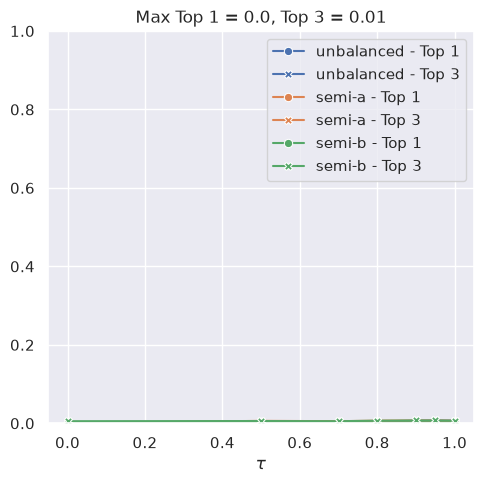


======== funSimAvg ========


100%|██████████| 3211/3211 [00:15<00:00, 211.94it/s]


======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.190 (426/2237)
Top-3 accuracy : 0.220 (492/2237)
Top-5 accuracy : 0.222 (496/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.107 (240/2237)
Top-3 accuracy : 0.218 (488/2237)
Top-5 accuracy : 0.220 (492/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.107 (240/2237)
Top-3 accuracy : 0.218 (487/2237)
Top-5 accuracy : 0.220 (492/2237)
 Rang moyen des maladies Orpha : 1266.12
 Rang moyen des maladies Omim : 1990.13
======== Avec régularisation ========
0.00828478812243653
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.128 (286/2237)
Top-3 accuracy : 0.230 (515/2237)
Top-5 accuracy : 0.293 (655/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.072 (160/2237)
Top-3 accuracy : 0.137 (306/2237)
Top-5 accuracy : 0.187 (418/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.049 (109/2237)
Top-3 accuracy : 0.

100%|██████████| 3/3 [01:08<00:00, 22.83s/it]


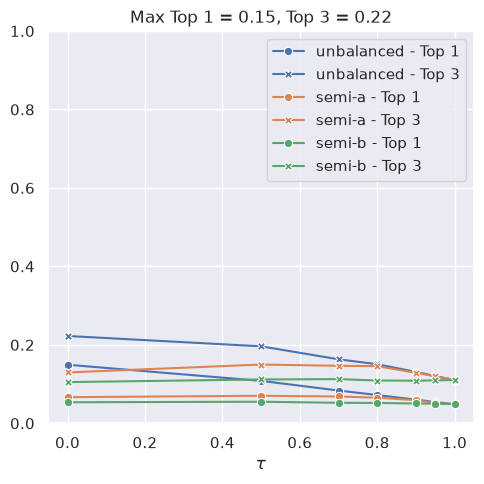


======== funSimMax ========


100%|██████████| 3211/3211 [00:11<00:00, 269.58it/s]


======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.240 (537/2237)
Top-3 accuracy : 0.262 (586/2237)
Top-5 accuracy : 0.264 (590/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.143 (321/2237)
Top-3 accuracy : 0.261 (583/2237)
Top-5 accuracy : 0.263 (588/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.143 (321/2237)
Top-3 accuracy : 0.259 (580/2237)
Top-5 accuracy : 0.263 (588/2237)
 Rang moyen des maladies Orpha : 1215.23
 Rang moyen des maladies Omim : 1831.25
======== Avec régularisation ========
0.005604389144243594
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.058 (129/2237)
Top-3 accuracy : 0.116 (259/2237)
Top-5 accuracy : 0.154 (344/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.037 (82/2237)
Top-3 accuracy : 0.079 (177/2237)
Top-5 accuracy : 0.104 (233/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.019 (42/2237)
Top-3 accuracy : 0.0

100%|██████████| 3/3 [01:03<00:00, 21.17s/it]


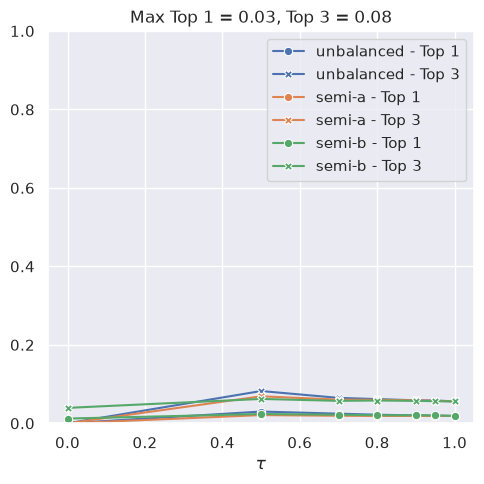


======== bma ========


100%|██████████| 3211/3211 [00:11<00:00, 268.67it/s]


======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.156 (348/2237)
Top-3 accuracy : 0.181 (405/2237)
Top-5 accuracy : 0.183 (409/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.092 (206/2237)
Top-3 accuracy : 0.180 (403/2237)
Top-5 accuracy : 0.181 (406/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.092 (206/2237)
Top-3 accuracy : 0.179 (401/2237)
Top-5 accuracy : 0.181 (406/2237)
 Rang moyen des maladies Orpha : 1328.81
 Rang moyen des maladies Omim : 2085.42
======== Avec régularisation ========
0.009607724638596151
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.127 (285/2237)
Top-3 accuracy : 0.220 (492/2237)
Top-5 accuracy : 0.278 (622/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.061 (137/2237)
Top-3 accuracy : 0.119 (266/2237)
Top-5 accuracy : 0.156 (350/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.039 (88/2237)
Top-3 accuracy : 0.

100%|██████████| 3/3 [01:08<00:00, 22.72s/it]


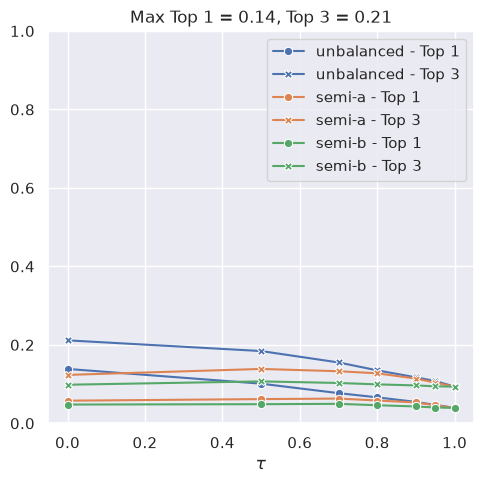

In [16]:
list_methods = ['max', 'mean', 'funSimAvg', 'funSimMax', 'bma']
taus = [0., 0.5, 0.7, 0.8, 0.9, 0.95, 1.]
for method in list_methods:
    print(f"======== {method} ========")
    C = resnik_disease_similarities(work_omim2, work_orpha2, hpo_sim, method)
    print("======== Sans régularisation ========")
    ot_plan, ot_cost = compute_transport(C, a=None, b=None)
    ranks, _, pairs, _, _ = evaluate_transport(ot_plan, gt_set2, C)

    # Avec régularisation
    print("======== Avec régularisation ========")
    grid = np.linspace(0.01, 5, 100)
    epsilon = grid[3]*np.mean(C)
    print(epsilon)
    ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 100000, 1e-4, False)
    ranks_reg, _, pairs_reg, _, _ = evaluate_transport(ot_plan_reg, gt_set2, C)
    plot_unbalanced(taus, C, epsilon, gt_set2)
    print()

#C_max = resnik_disease_similarities(work_omim, work_orpha, hpo_sim, 'max')
#C_mean = resnik_disease_similarities(work_omim, work_orpha, hpo_sim, 'mean')
#C_funSimAvg = resnik_disease_similarities(work_omim, work_orpha, hpo_sim, 'funSimAvg')
#C_funSimMax = resnik_disease_similarities(work_omim2, work_orpha2, hpo_sim, 'funSimMax')
#C_bma = resnik_disease_similarities(work_omim, work_orpha, hpo_sim, 'bma')

## Comparaison des résultats des différentes méthodes

In [8]:
dict_method = load_all_methods()

### Corrélations des matrices de coût

In [10]:
inter = np.zeros((len(dict_method.keys()), len(dict_method.keys())))
inter_null = np.zeros((len(dict_method.keys()), len(dict_method.keys())))

# Paires systématiquement correctes et incorrectes
overall_correct = gt_set
overall_incorrect = gt_set

correct_lines = gt_set
incorrect_lines = gt_set

correct_cols = gt_set
incorrect_cols = gt_set

# Matrice des corrélations entre coûts
cost_corr = np.zeros((len(dict_method), len(dict_method)))

k=3
for i, method1 in enumerate(dict_method.keys()):
    C1 = dict_method[method1]["cost_matrix"].flatten()
    P1 = dict_method[method1]["ot_plan"]
    ranks1 = read_transport_plan(P1, gt_set2)

    correct_pairs1 = [u for u, v in ranks1.items() if (v[0]<=k and v[1]<=k)]
    incorrect_pairs1 = [u for u, v in ranks1.items() if (v[0]>k and v[1]>k)]
    overall_correct = overall_correct & set(correct_pairs1)
    overall_incorrect = overall_incorrect & set(incorrect_pairs1)
    
    correct_lines1 = [u for u, v in ranks1.items() if v[0]<=k]
    incorrect_lines1 = [u for u, v in ranks1.items() if v[0]>k]
    correct_lines = correct_lines & set(correct_lines1)
    incorrect_lines = incorrect_lines & set(incorrect_lines1)

    correct_cols1 = [u for u, v in ranks1.items() if v[1]<=k]
    incorrect_cols1 = [u for u, v in ranks1.items() if v[1]>k]
    correct_cols = correct_cols & set(correct_cols1)
    incorrect_cols = incorrect_cols & set(incorrect_cols1)
    
    for j, method2 in enumerate(dict_method.keys()):
        C2 = dict_method[method2]["cost_matrix"].flatten()
        P2 = dict_method[method2]["ot_plan"]
        ranks2 = read_transport_plan(P2, gt_set2)

        cost_corr[i, j]=np.corrcoef(C1, C2)[0,1]

        correct_pairs2 = [u for u, v in ranks2.items() if (v[0]<=k and v[1]<=k)]
        incorrect_pairs2 = [u for u, v in ranks2.items() if (v[0]>k and v[1]>k)]
        overall_correct = overall_correct & set(correct_pairs2)
        overall_incorrect = overall_incorrect & set(incorrect_pairs2)
        
        correct_lines2 = [u for u, v in ranks2.items() if v[0]<=k]
        incorrect_lines2 = [u for u, v in ranks2.items() if v[0]>k]
        correct_lines = correct_lines & set(correct_lines2)
        incorrect_lines = incorrect_lines & set(incorrect_lines2)

        correct_cols2 = [u for u, v in ranks2.items() if v[1]<=k]
        incorrect_cols2 = [u for u, v in ranks2.items() if v[1]>k]
        correct_cols = correct_cols & set(correct_cols1)
        incorrect_cols = incorrect_cols & set(incorrect_cols1)

        inter[i, j] = np.round(len(set(correct_pairs1)&set(correct_pairs2))/len(correct_pairs2)*100, 0)
        inter_null[i, j] = np.round(len((set(incorrect_pairs1)&set(incorrect_pairs2)))/len(incorrect_pairs1)*100, 0)

# Corrélation entre les matrices de coûts
print(dict_method.keys())
print(cost_corr)
print()

# Paires communes correctement ou incorrectement transportées
print(dict_method.keys())
print("Paires correctement transportées en commun")
print(inter)
print("Paires incorrectement transportées en commun")
print(inter_null)
print("Check : ", overall_correct&overall_incorrect)
print()

print(f"Overall correct : {len(overall_correct)}, Overall incorrect : {len(overall_incorrect)}")
print(f"Correct lines : {len(correct_lines)} ; Incorrect lines : {len(incorrect_lines)}")
print(f"Correct columns : {len(correct_cols)} ; Incorrect columns : {len(incorrect_cols)}")

dict_keys(['embedding_wasserstein', 'correlation', 'profondeur reg', 'embedding_hamming', 'hamming reg', 'jaccard reg', 'ic'])
[[ 1.          0.66470878 -0.2459274  -0.22119499 -0.21448326  0.68705015
  -0.21039663]
 [ 0.66470878  1.         -0.29693844 -0.29271789 -0.26959761  0.97700182
  -0.27661995]
 [-0.2459274  -0.29693844  1.          0.99219556  0.99251485 -0.26919421
   0.98900109]
 [-0.22119499 -0.29271789  0.99219556  1.          0.99686741 -0.26592898
   0.99749622]
 [-0.21448326 -0.26959761  0.99251485  0.99686741  1.         -0.24030491
   0.9959177 ]
 [ 0.68705015  0.97700182 -0.26919421 -0.26592898 -0.24030491  1.
  -0.25031092]
 [-0.21039663 -0.27661995  0.98900109  0.99749622  0.9959177  -0.25031092
   1.        ]]

dict_keys(['embedding_wasserstein', 'correlation', 'profondeur reg', 'embedding_hamming', 'hamming reg', 'jaccard reg', 'ic'])
Paires correctement transportées en commun
[[100.  87.  90.  89.  90.  90.  89.]
 [ 92. 100.  94.  93.  95.  97.  93.]
 [ 87.  86

In [11]:
# Maladies correctement/incorrectement transportées
paires_zero_dict = build_pairs_dictionary(overall_incorrect, work_omim2, work_orpha2, df_hpoa)
paires_correct_dict = build_pairs_dictionary(overall_correct, work_omim2, work_orpha2, df_hpoa)

correct_lines_dict = build_pairs_dictionary(correct_lines, work_omim2, work_orpha2, df_hpoa)
incorrect_lines_dict = build_pairs_dictionary(incorrect_lines, work_omim2, work_orpha2, df_hpoa)

correct_cols_dict = build_pairs_dictionary(correct_cols, work_omim2, work_orpha2, df_hpoa)
incorrect_cols_dict = build_pairs_dictionary(incorrect_cols, work_omim2, work_orpha2, df_hpoa)

### Termes HPO en commun

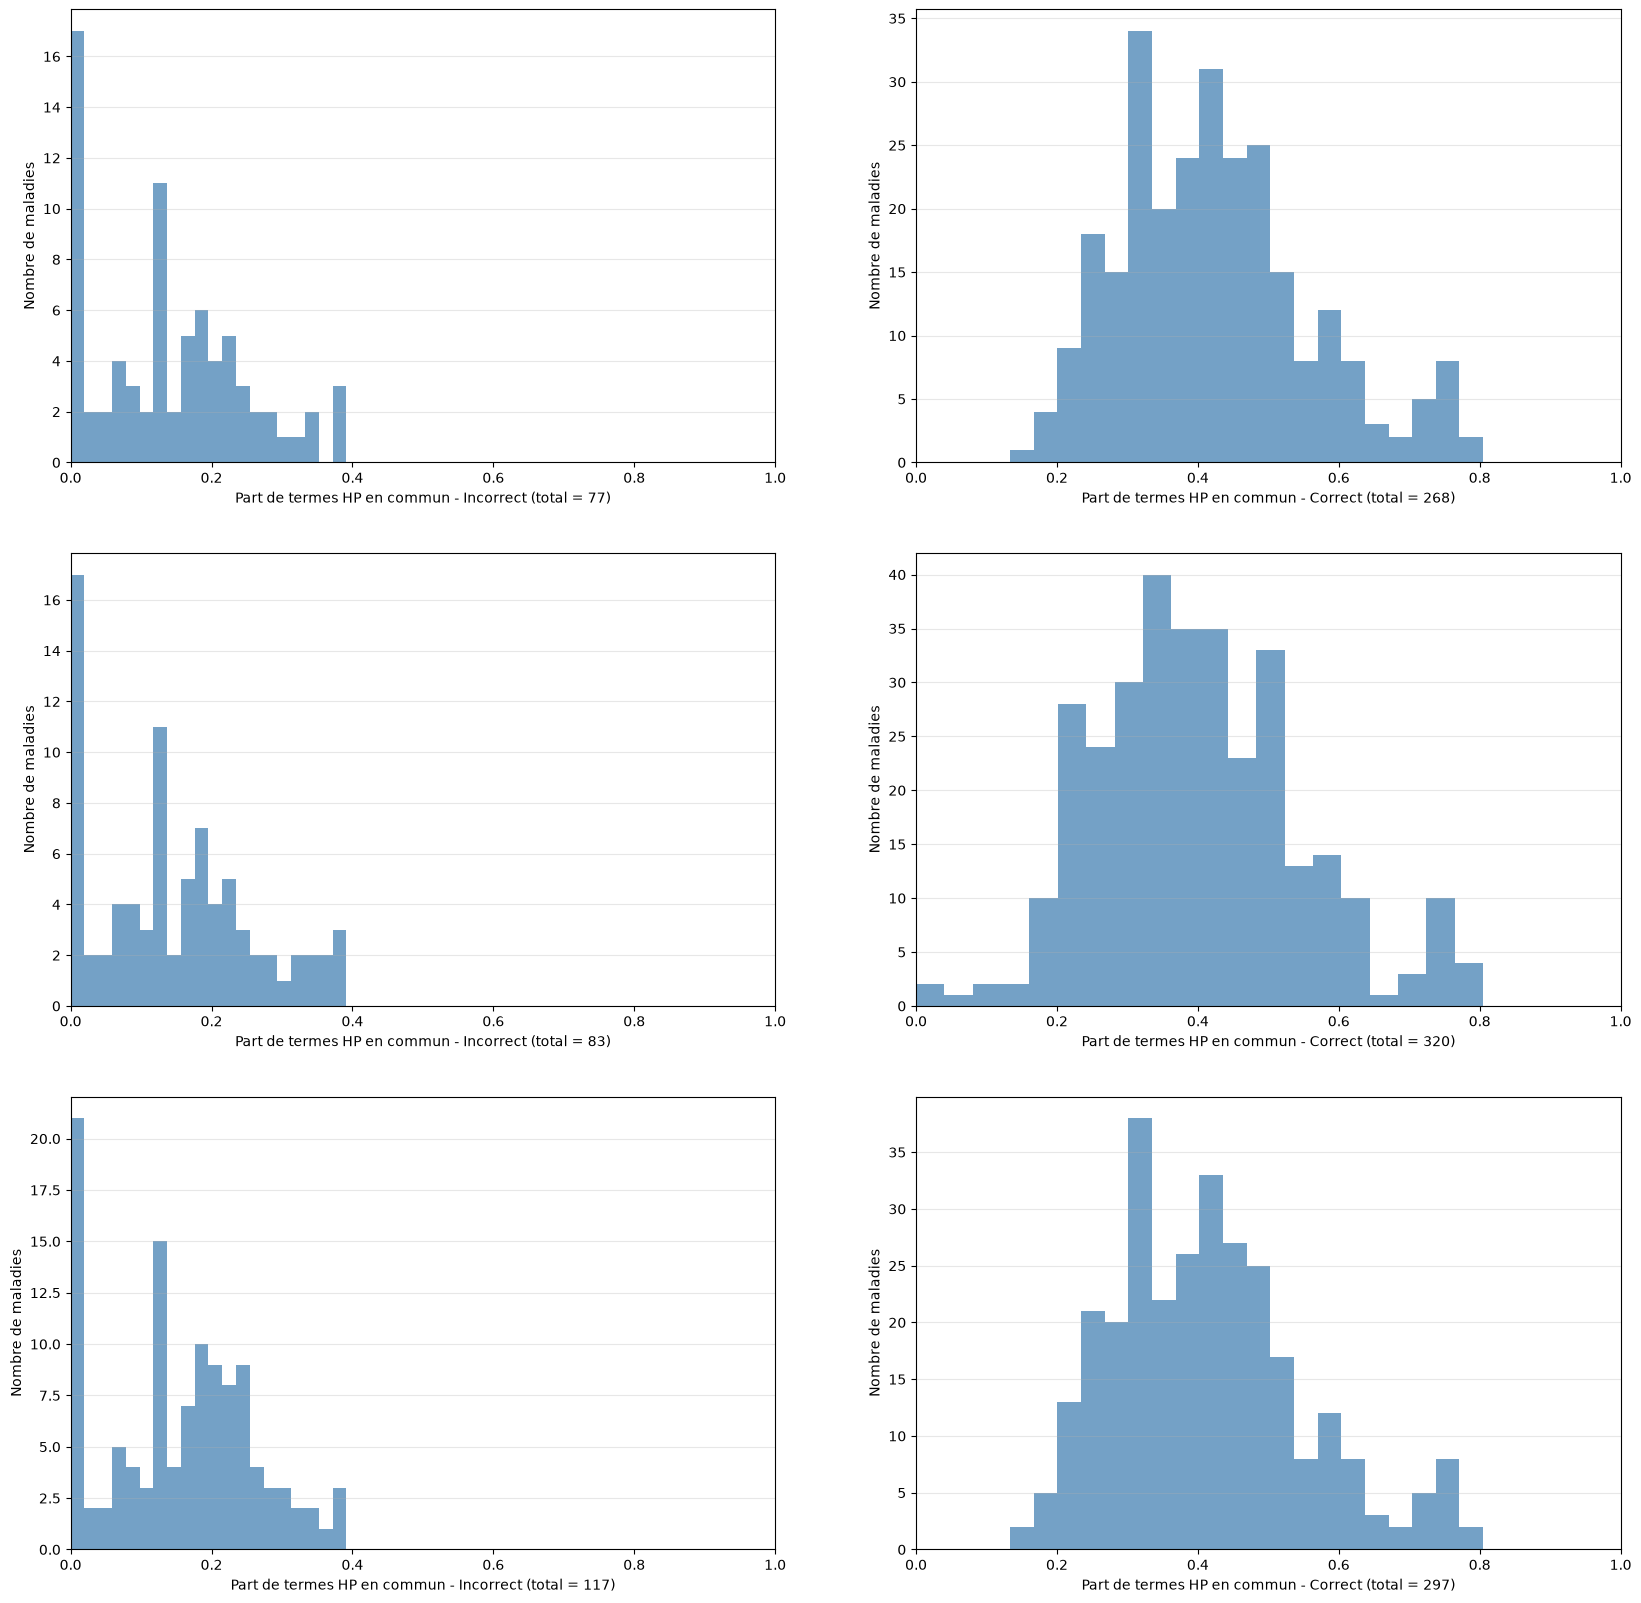

In [12]:
# Histplot part de termes en commun entre maladies omim et orpha
def score(d):
    return [
        2 * len(entry["commun"]) / (entry["omim"]["count"] + entry["orpha"]["count"])
        for entry in d.values()
    ]
fig, axes = plt.subplots(3, 2, figsize=(20, 20))

panels = [
    (paires_zero_dict,     len(overall_incorrect), "Incorrect"),
    (paires_correct_dict,  len(overall_correct),   "Correct"),
    (incorrect_lines_dict, len(incorrect_lines),   "Incorrect"),
    (correct_lines_dict,   len(correct_lines),     "Correct"),
    (incorrect_cols_dict,  len(incorrect_cols),    "Incorrect"),
    (correct_cols_dict,    len(correct_cols),      "Correct"),
]

for ax, (data_dict, total, label) in zip(axes.flat, panels):
    values = score(data_dict)
    sns.histplot(values, bins=20, ax=ax, color='steelblue', edgecolor='none')
    ax.set_xlabel(f"Part de termes HP en commun - {label} (total = {total})")
    ax.set_ylabel("Nombre de maladies")
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(0, 1)
    
plt.show()

### *Information content*

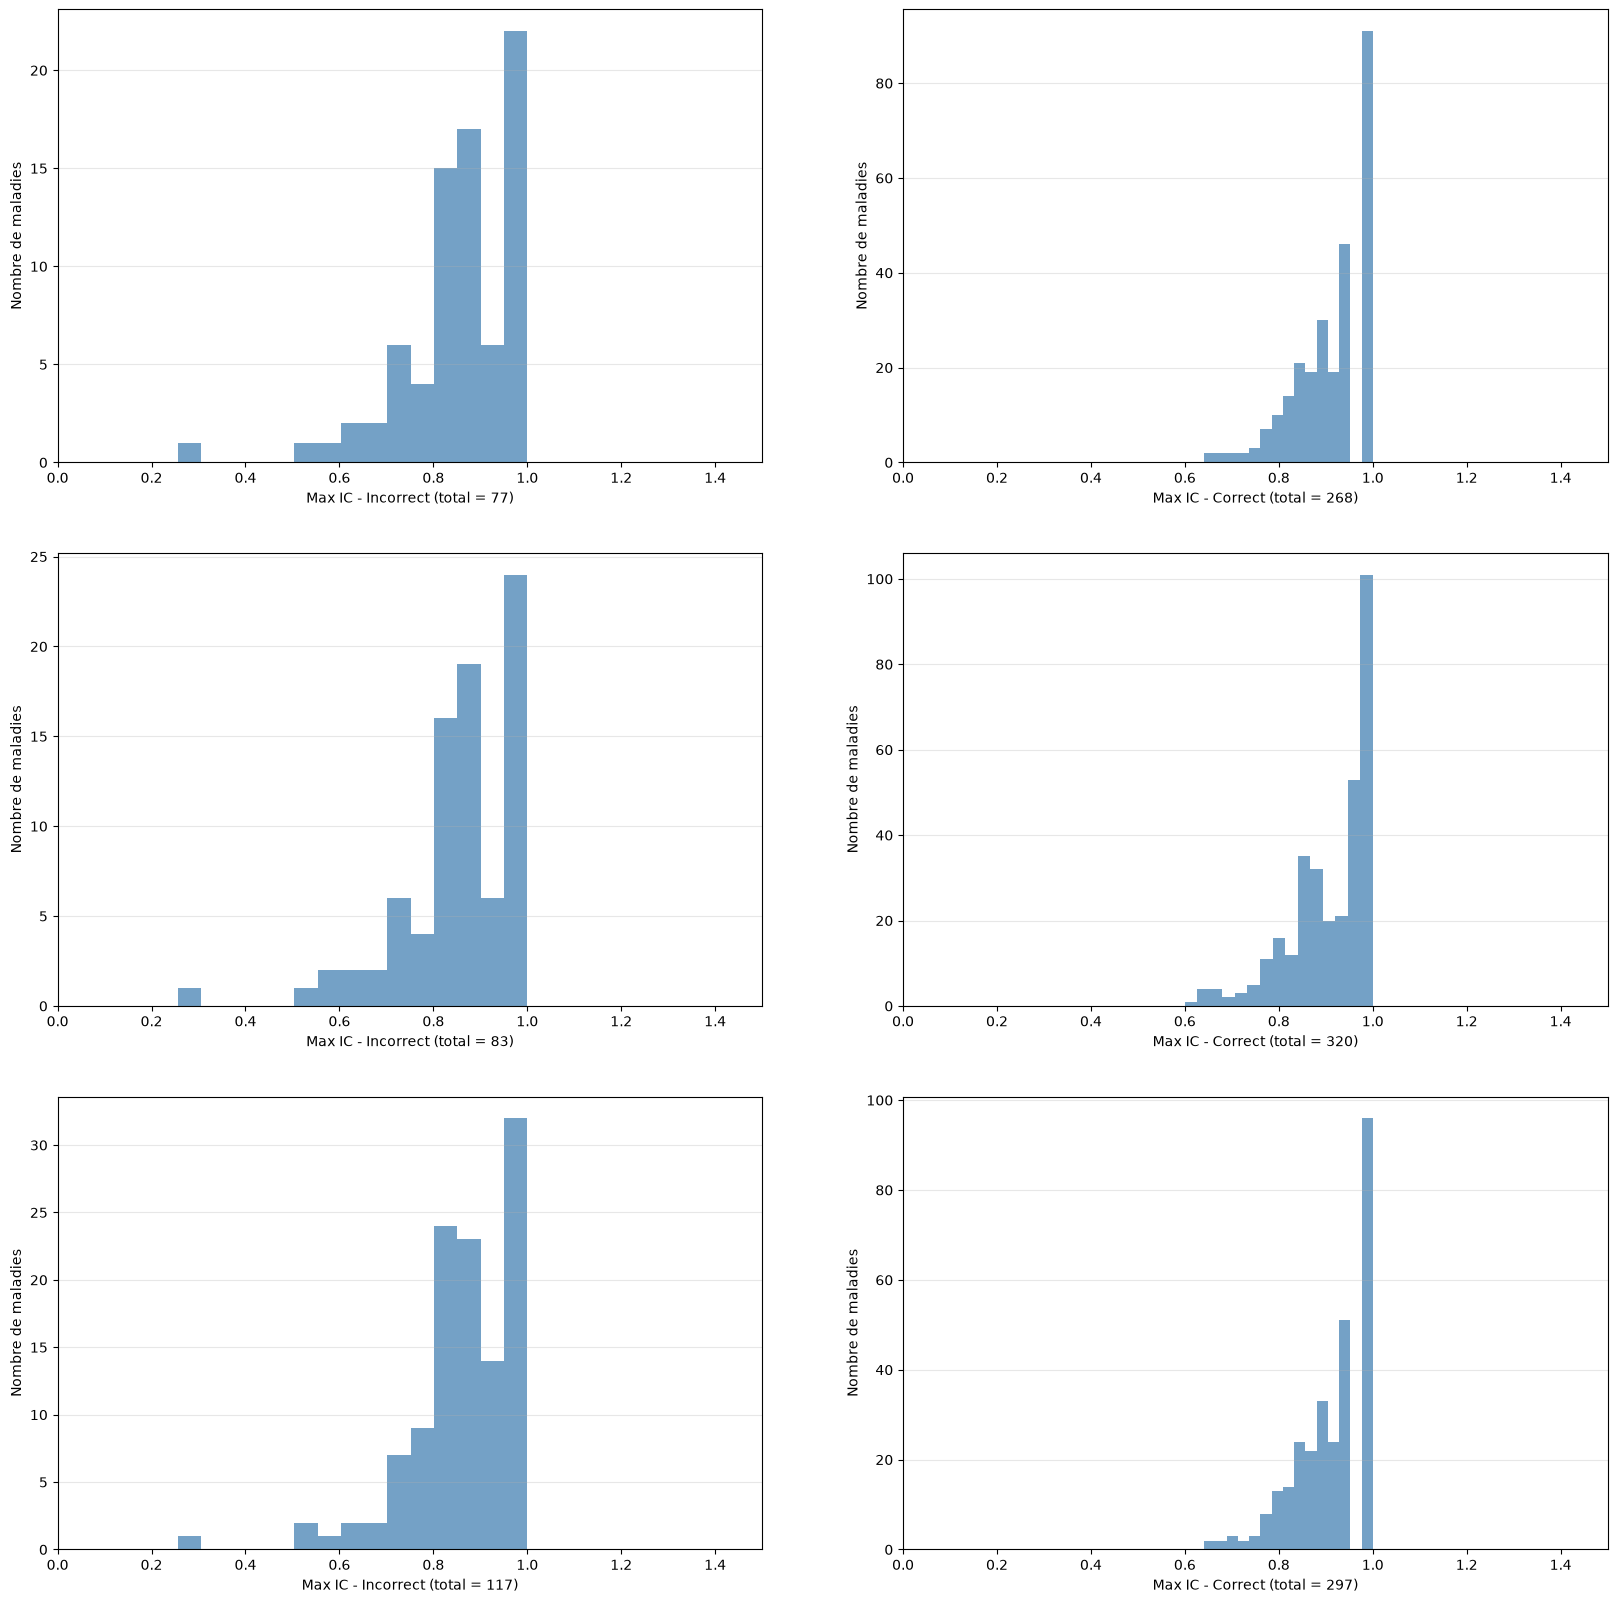

In [14]:
# Différences en terme d'information content
def max_ic(terms, ic):
    max_ic = ic[max(ic)]
    vals = [ic.get(t, 0)/max_ic for t in terms if t in ic]
    return np.max(vals) if vals else 0


def ic_score(d):
    return [
        max_ic(entry["omim"]["terms"], weights_all) for entry in d.values()
    ]

panels = [
    (paires_zero_dict,     len(overall_incorrect), "Incorrect"),
    (paires_correct_dict,  len(overall_correct),   "Correct"),
    (incorrect_lines_dict, len(incorrect_lines),   "Incorrect"),
    (correct_lines_dict,   len(correct_lines),     "Correct"),
    (incorrect_cols_dict,  len(incorrect_cols),    "Incorrect"),
    (correct_cols_dict,    len(correct_cols),      "Correct"),
]
fig, axes = plt.subplots(3, 2, figsize=(20, 20))

for ax, (data_dict, total, label) in zip(axes.flat, panels):
    values = ic_score(data_dict)
    sns.histplot(values, bins=15, ax=ax, color='steelblue', edgecolor='none')
    ax.set_xlabel(f"Max IC - {label} (total = {total})")
    ax.set_ylabel("Nombre de maladies")
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(0,1.5)
    
plt.show()

### Plus court chemin

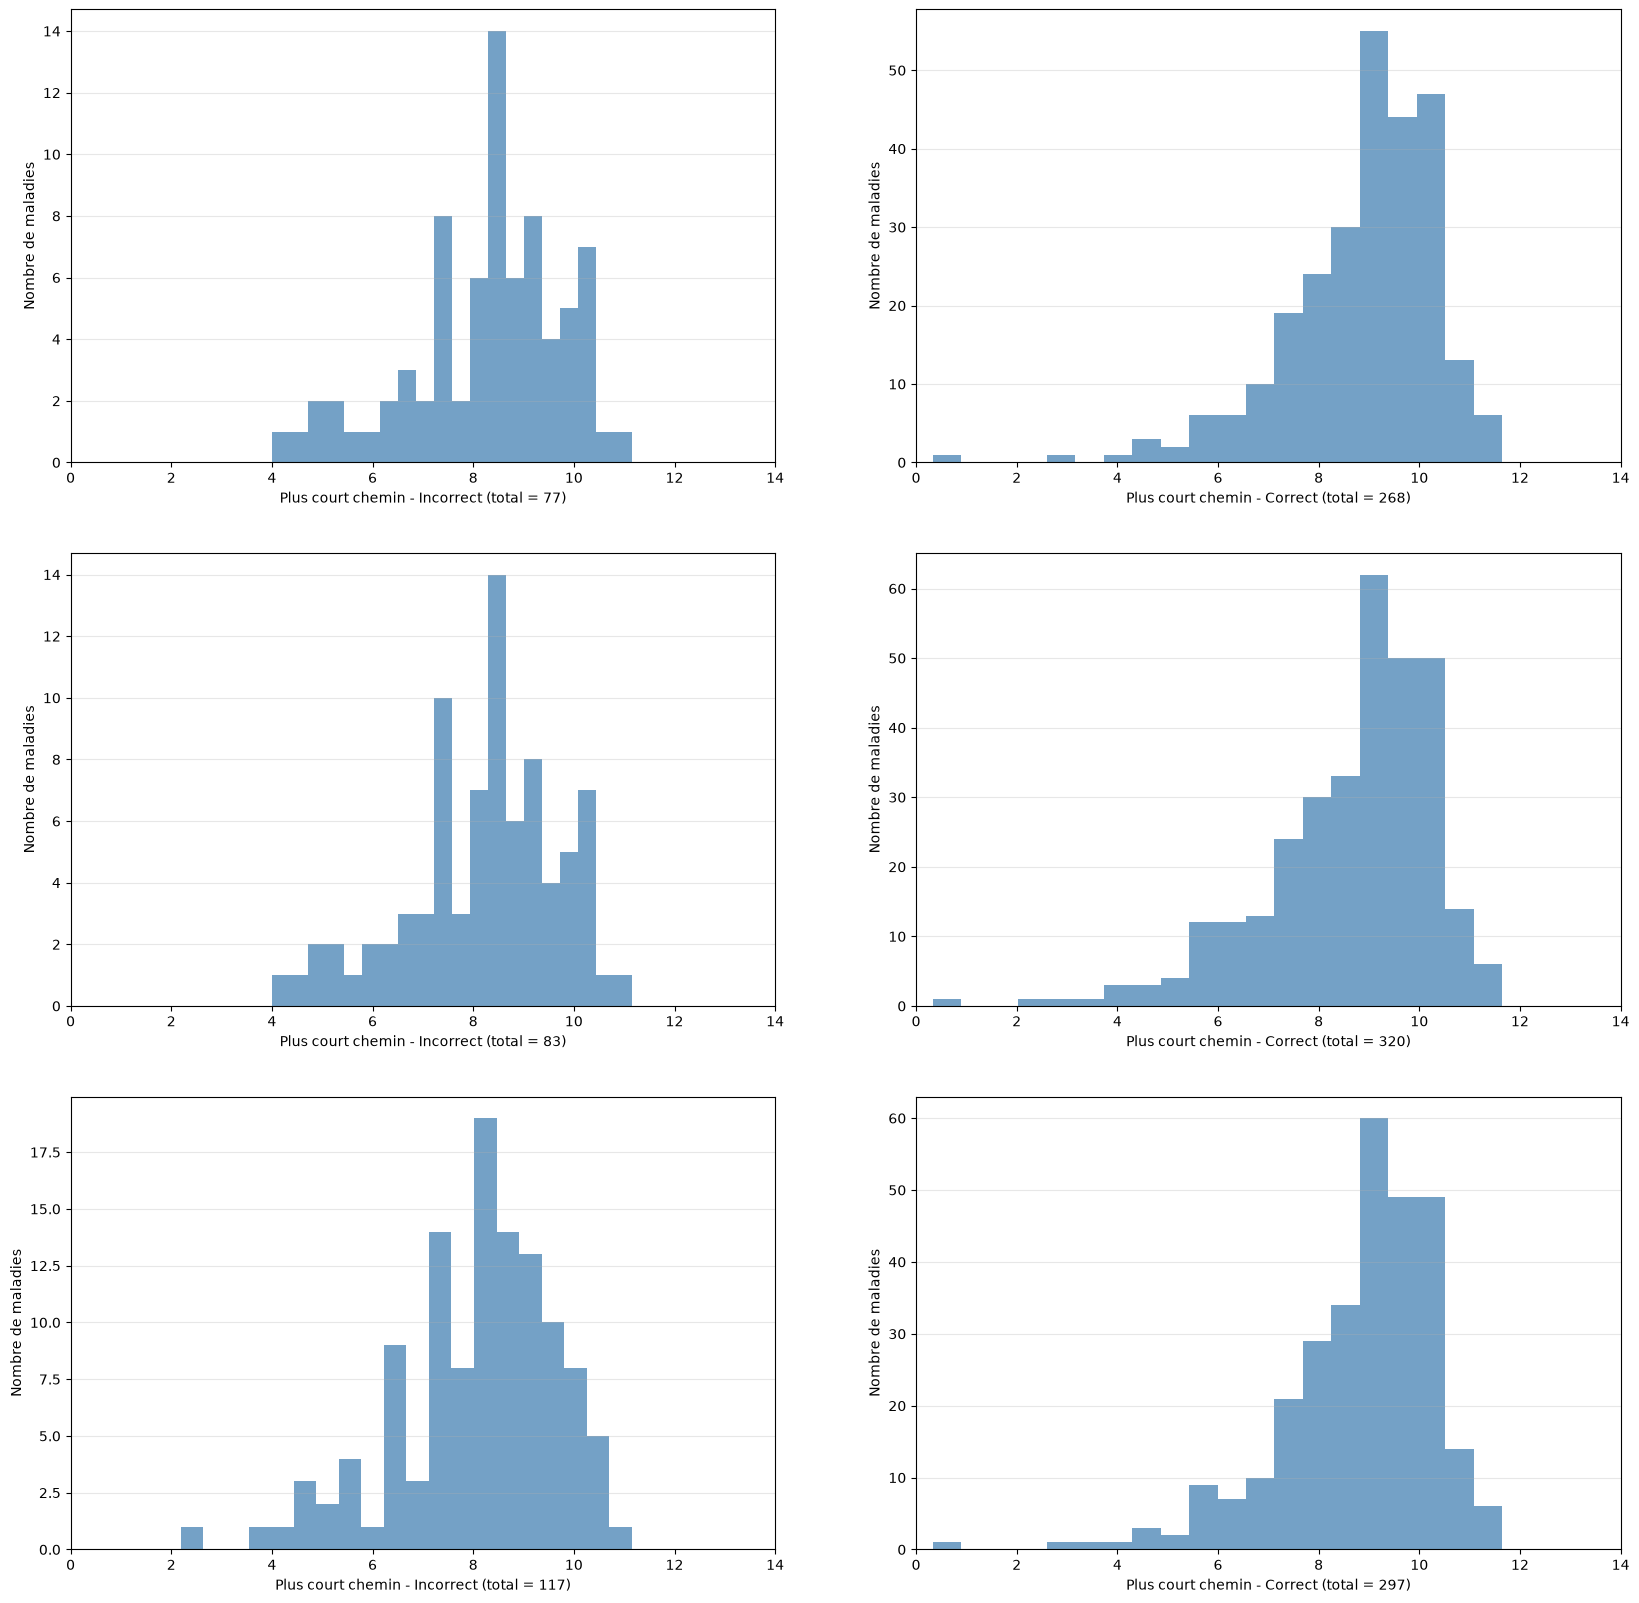

In [34]:
def lca_score(d, depths, ancestors):
    return [
        max(
            shortest_path(entry['omim']['terms'], entry['orpha']['terms'], depths, ancestors),
            shortest_path(entry['orpha']['terms'], entry['omim']['terms'], depths, ancestors)
        )
        for entry in d.values()
    ]

ancestors = {t: get_ancestors0(G_hpo_work, t) | {t} for t in hpo_cols2}

panels = [
    (paires_zero_dict,     len(overall_incorrect), "Incorrect"),
    (paires_correct_dict,  len(overall_correct),   "Correct"),
    (incorrect_lines_dict, len(incorrect_lines),   "Incorrect"),
    (correct_lines_dict,   len(correct_lines),     "Correct"),
    (incorrect_cols_dict,  len(incorrect_cols),    "Incorrect"),
    (correct_cols_dict,    len(correct_cols),      "Correct"),
]

fig, axes = plt.subplots(3, 2, figsize=(20, 20))

for ax, (data_dict, total, label) in zip(axes.flat, panels):
    values = lca_score(data_dict, depths, ancestors)
    sns.histplot(values, bins=20, ax=ax, color='steelblue', edgecolor='none')
    ax.set_xlabel(f"Plus court chemin - {label} (total = {total})")
    ax.set_ylabel("Nombre de maladies")
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(0, 14)
    
plt.show()

## Autres distances de Wasserstein qui n'exploitent pas l'*embedding*

In [40]:
def cost_matrix_wasserstein_lca(df_omim, df_orpha, node2id_w, ancestors, depths, deprecated):
    hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]

    print("Precompute...")
    def precompute(df):
        '''
        Renvoie pour chaque maladie (ligne) du dataframe df la liste des termes HPO actifs et 
        le vecteur de poids uniformes associés.
        '''
        X = df[hpo_cols].to_numpy(dtype=bool)
        resolved_cols = np.array(
            [deprecated.get(col, col) if deprecated.get(col, col) in node2id_w else None for col in hpo_cols], 
            dtype=object)
        valid_mask = resolved_cols != None
        X_valid = X[:, valid_mask]
        resolved_valid = resolved_cols[valid_mask]
        terms = [list(resolved_valid[row_mask]) for row_mask in X_valid]
        weights = [np.ones(len(t)) / len(t) if t else np.array([]) for t in terms]
        return terms, weights

    terms_i, weights_i = precompute(df_omim)  # Termes actifs, poids pour les maladies sources
    terms_j, weights_j = precompute(df_orpha)  # Termes actifs, poids pour les maladies destinations
    print("Finished !")

    all_terms = list({h for ts in terms_i + terms_j for h in ts})  # Tous les termes actifs

    print("Precomputing full HPO distance matrix...")
    K = len(all_terms)
    D_full = np.zeros((K, K))
    for i in tqdm(range(K), desc='Matrice de couts premier transport'):
        for j in range(i+1, K):
            lca, d_lca = find_lca(all_terms[i], all_terms[j], ancestors, depths)
            D_full[i, j] = (depths[all_terms[i]] + depths[all_terms[j]] - 2*d_lca) #/(d_lca+1)
            D_full[j, i] = (depths[all_terms[i]] + depths[all_terms[j]] - 2*d_lca) #/(d_lca+1)
    print(f"HPO distance matrix: {D_full.shape}")
    return D_full

D_hpos = cost_matrix_wasserstein_lca(work_omim0, work_orpha0, node2id_w, ancestors, depths, deprecated)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Matrice de couts premier transport:  57%|█████▋    | 6032/10649 [03:26<02:37, 29.25it/s]


KeyboardInterrupt: 

## Ajout d'une régularisation Laplacienne en utilisant les PPI

On considère que deux maladies sont similaires si leurs protéines interagissent ensemble.

In [21]:
def simi_ppi(df):
    n = df.shape[0]
    protein_to_idx = defaultdict(list)
    for i, row in df.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx[p].append(i)

    S = np.zeros((n, n))
    for i, row in df.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_j = protein_to_idx.get(p)
            if list_j is not None :
                for j in list_j:
                    S[i, j]=1
                    S[j, i]=1
    return S

df1_omim0 = df1_omim[df1_omim['disease_id'].isin(work_omim0['database_id'])].reset_index()
df1_orpha0 = df1_orpha[df1_orpha['disease_id'].isin(work_orpha0['database_id'])].reset_index()

simi_source = simi_ppi(df1_omim0)
simi_target = simi_ppi(df1_orpha0)

Text(0.5, 1.0, 'Target')

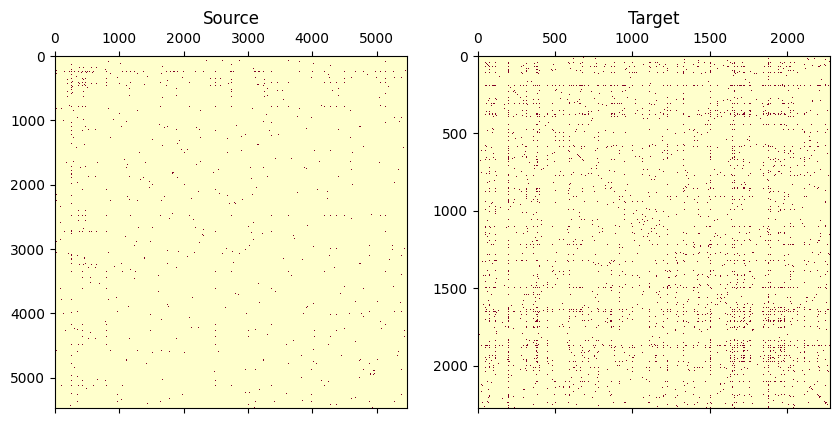

In [35]:
# Matrices de similarités : il faudrait ordonner les colonnes selon gene_gt_set ? 
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].matshow(simi_source, cmap="YlOrRd")
axes[0].set_title("Source")
axes[1].matshow(simi_target, cmap="YlOrRd")
axes[1].set_title("Target")

In [ ]:
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_array
n_comp1, labels1 = connected_components(csr_array(simi_source))
print(n_comp1)
n_comp2, labels2 = connected_components(csr_array(simi_target))
print(n_comp2)

1
1


In [15]:
def gcg0(a,
    b,
    M,
    f,
    df,
    reg1,
    reg2,
    lp_solver,
    line_search,
    G0=None,
    numItermax=200,
    stopThr=1e-9,
    stopThr2=1e-9,
    **kwargs
    #log=False
    ):
    loop = 1
    #if log:
        #log = {"loss": []}
    if G0 is None:
        G = np.outer(a, b)
    else:
        G = np.copy(G0)
    if reg2 is None:
        def cost(G):
            return np.sum(M * G) + reg1 * f(G)
    else:
        def cost(G):
            return np.sum(M * G) + reg1 * f(G) + reg2 * np.sum(G * np.log(G))
    cost_G = cost(G)
    #if log:
        #log["loss"].append(cost_G)
    df_G = None
    it = 0
    while loop:
        it += 1
        old_cost_G = cost_G
        # problem linearization
        if df_G is None:
            df_G = df(G)
        Mi = M + reg1 * df_G
        if reg2 is not None:
            Mi = Mi + reg2 * (1 + nx.log(G))

        # solve linear program
        Gc, innerlog_ = lp_solver(a, b, Mi, **kwargs)
        # line search
        deltaG = Gc - G

        res_line_search = line_search(cost, G, deltaG, Mi, cost_G, df_G, **kwargs)
        if len(res_line_search) == 3:
            # the line-search does not allow to update the gradient
            alpha, fc, cost_G = res_line_search
            df_G = None
        else:
            # the line-search allows to update the gradient directly
            # e.g. while using quadratic losses as the gromov-wasserstein loss
            alpha, fc, cost_G, df_G = res_line_search

        G = G + alpha * deltaG

        # test convergence
        if it >= numItermax:
            loop = 0

        abs_delta_cost_G = abs(cost_G - old_cost_G)
        relative_delta_cost_G = (
            abs_delta_cost_G / abs(cost_G) if cost_G != 0.0 else np.nan
        )
        if relative_delta_cost_G < stopThr or abs_delta_cost_G < stopThr2:
            loop = 0

        #if log:
            #log["loss"].append(cost_G)
    return G

In [ ]:
# Inspiré du code emd_laplace de la librairie POT
from ot import sinkhorn
from ot.optim import cg, gcg
from sklearn.neighbors import kneighbors_graph

def laplacian(x):
    r"""Compute Laplacian matrix"""
    L = np.diag(np.sum(x, axis=1)) - x
    return L

def otda(
    a, b, 
    df_source, df_target, 
    C, 
    Ss, St,
    epsilon,
    eta=1., 
    alpha=0.5, 
    reg="pos", 
    numItermax=1000,
    stopThr=1e-9,
    numInnerItermax=10_000,
    stopInnerThr=1e-9,
    log=False,
    verbose=False):

    n, m = C.shape
    if a is None:
        a = np.ones(n)/n
    if b is None:
        b = np.ones(m)/m

    xs = np.asarray(df_source, dtype=np.float64)
    xt = np.asarray(df_target, dtype=np.float64)
    print('xs', xs.shape)
    print('xt', xt.shape)
    if Ss is None or St is None :
        sim_param = 10
        Ss = kneighbors_graph(X=xs, n_neighbors=int(sim_param)).toarray()
        St = kneighbors_graph(X=xt, n_neighbors=int(sim_param)).toarray()
    sS = (Ss + Ss.T) / 2  
    sT = (St + St.T) / 2
    print('sS', sS.shape)
    print('sT', sT.shape)
    print("sS symétrique ?", np.allclose(sS, sS.T))
    print("sS valeurs négatives ?", (sS < 0).any())
    print("diag(sS) :", np.diag(sS)[:5])

    lS = laplacian(sS)
    lT = laplacian(sT)
    print('lS', lS.shape)
    print('lT', lT.shape)

    ls2 = lS + lS.T
    lt2 = lT + lT.T
    xt2 = np.dot(xt, xt.T)
    xs2 = np.dot(xs, xs.T)

    if reg == "disp":
        Cs = -eta * alpha / xs.shape[0] *(ls2 @ xs @ xt.T)
        Ct = -eta * (1 - alpha) / xt.shape[0] * (xs @ xt.T @ lt2)
        C = C + Cs + Ct

    def f(G):
        #GXt = G @ xt
        #term1 = np.einsum('ij,ij->', lS @ GXt, GXt)
        #term1 = np.trace(G.T.dot(ls2*0.5).dot(G))
        #GtXs = G.T @ xs
        #term2 = np.einsum('ij,ij->', lT @ GtXs, GtXs)
        #term2 = np.trace(G.dot(lt2*0.5).dot(G.T))
        #return alpha * term1 + (1 - alpha) * term2
        return alpha * np.trace(xt.T @ G.T @ lS @ G @ xt) + (1 - alpha) * np.trace(xs.T @ G @ lT @ G.T @ xs)

    def df(G):
        #return alpha * (ls2 @ G) + (1-alpha) * (G @ lt2)
        return alpha * (ls2 @ G @ xt2) + (1 - alpha) * (xs2 @ G @ lt2)

    assert (C >= 0).all(), "C contient des valeurs négatives !"
    G_emd = sinkhorn(a, b, C, reg=epsilon*np.mean(C), numItermax=10_000)
    G_emd = G_emd/G_emd.sum()
    print("G0 nan:", np.isnan(G_emd).any())
    G0Xt = G_emd @ xt
    term1 = np.einsum('ij,ij->', lS @ G0Xt, G0Xt)
    G0tXs = G_emd.T @ xs
    term2 = np.einsum('ij,ij->', lT @ G0tXs, G0tXs)
    f_Gemd = alpha * term1 + (1 - alpha) * term2

    print("f(G_emd):", f_Gemd) 
    print("⟨G_emd, C⟩ :", np.sum(G_emd * C))
    print("ratio :", np.sum(G_emd * C) / f_Gemd)
    eta_calibrated = np.sum(G_emd*C)/f_Gemd
    return gcg(
        a,
        b,
        C,
        reg1=eta_calibrated*eta,
        reg2=epsilon,
        f=f,
        df=df,
        G0=None,
        numItermax=100, 
        numInnerItermax=100_000, 
        stopThr=1e-09, 
        stopThr2=1e-09, 
        verbose=True
    )


'\n    def lp_solver(a, b, M, **kwargs):\n        return sinkhorn(a, b, M, reg=epsilon, \n                        numItermax=numInnerItermax,\n                        stopThr=1e-9)\n\n    G = a[:, None] * b[None, :]\n    print(\'G\', G.shape)\n    for i in tqdm(range(numItermax)):\n        M = C + eta * df(G)\n        G_new = sinkhorn(a, b, M, reg=epsilon,\n                         numItermax=numInnerItermax,\n                         stopThr=1e-9)\n        # Line search : pas optimal entre G et G_new\n        delta = G_new - G\n        G = G + 1.0 / (i + 2) * delta  # pas décroissant classique\n        err = np.max(np.abs(delta))\n        if verbose:\n            print(f"iter {i}: err={err:.2e}")\n        if err < stopThr:\n            break\n\n    return G\n'

In [22]:
work_omim00 = work_omim0[work_omim0['database_id'].isin(df1_omim0['disease_id'])].reset_index()
work_orpha00 = work_orpha0[work_orpha0['database_id'].isin(df1_orpha0['disease_id'])].reset_index()
work_cols = [c for c in work_omim00.columns if c.startswith("HP")]
gt_set00, valid_omim0, valid_orpha0 = f_ground_truth(work_omim00, work_orpha00, df_orpha_omim_exact)

In [ ]:
# weights, _, _ = compute_information_content(gene_omim, G_hpo_work)
# weights = {t:-np.log(w) for t, w in weights.items()}
print("Computing cost...")
C = basic_cost_matrix(work_omim00, work_orpha00, 'hamming')
print("Done !")
#grid = np.linspace(0.01, 5, 100)
#epsilon = grid[1]*np.mean(C)
#print(f"Epsilon = {epsilon}")
for eta in [0.01, 0.1, 1., 100, 1000]:
    for epsilon in [0.01, 0.1, 1, 10.]:
        epsilon0 = epsilon * np.mean(C)
        print(f"Eta = {eta} et Epsilon = {epsilon}")
        ot_lapl = otda(
        None, None,  # a, b
        work_omim00[work_cols], work_orpha00[work_cols], 
        C, 
        None, None,  # Ss, St
        epsilon, 
        eta, 
        alpha=0.5)
        print("transport computed")
        ranks_lapl, pairs_lapl = evaluate_transport(ot_lapl, gt_set00, C)

Computing cost...
Check : (5474, 2275)
Done !
Eta = 0.01 et Epsilon = 0.01
xs (5474, 11613)
xt (2275, 11613)
sS (5474, 5474)
sT (2275, 2275)
sS symétrique ? True
sS valeurs négatives ? False
diag(sS) : [0. 0. 0. 0. 0.]
lS (5474, 5474)
lT (2275, 2275)
G0 nan: False
f(G_emd): 0.01804051906013633
⟨G_emd, C⟩ : 37.604860799878885
ratio : 2084.4666760710547
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|-2.904971e+02|0.000000e+00|0.000000e+00
    1|-2.906549e+02|5.428216e-04|1.577738e-01
    2|-2.906549e+02|0.000000e+00|0.000000e+00
transport computed
Paires évaluées : 1583
Top-1 accuracy : 0.554 (877/1583)
Top-3 accuracy : 0.691 (1094/1583)
Top-5 accuracy : 0.752 (1190/1583)
 Rang moyen: 30.71
Eta = 0.01 et Epsilon = 0.1
xs (5474, 11613)
xt (2275, 11613)
sS (5474, 5474)
sT (2275, 2275)
sS symétrique ? True
sS valeurs négatives ? False
diag(sS) : [0. 0. 0. 0. 0.]
lS (5474, 5474)
lT (2275, 2275)
G0 nan: False
f(G_emd): 0.00159984065335012

## Essai de Fused Gromov Wasserstein

In [6]:
def simi_ppi_crossed(df1, df2):
    n = df1.shape[0]
    m = df2.shape[0]
    protein_to_idx1 = defaultdict(list)
    protein_to_idx2 = defaultdict(list)
    for i, row in df1.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx1[p].append(i)
    for j, row in df2.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx2[p].append(j)
    S = np.zeros((n, m))

    for i, row in df1.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_j = protein_to_idx2.get(p)
            if list_j is not None :
                for j in list_j:
                    S[i, j]=1
    # Check
    S_transp = np.zeros((m, n))
    for j, row in df2.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_i = protein_to_idx1.get(p)
            if list_i is not None:
                for i in list_i:
                    S_transp[j, i]=1
                    if S_transp[j, i]!=S[i, j]:
                        print("p", p)
                        print("i", i)
                        print(row)
    assert np.array_equal(S_transp.T, S), "Les deux matrices doivent être égales"
    return S, S_transp

simi_omim_orpha, S_transp = simi_ppi_crossed(df1_omim0, df1_orpha0)

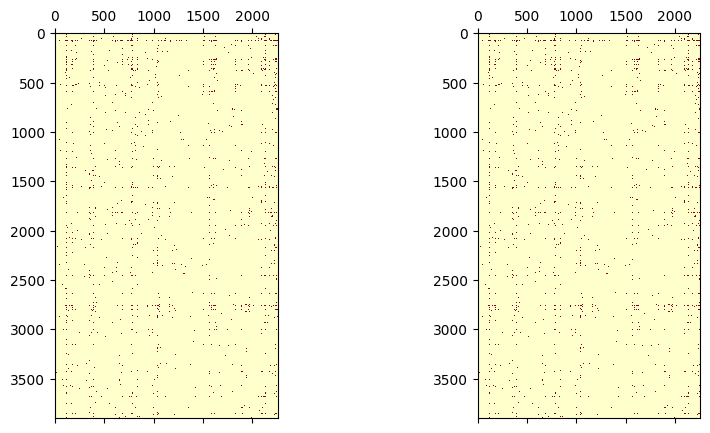

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].matshow(simi_omim_orpha, cmap="YlOrRd")
axes[1].matshow(S_transp.T, cmap="YlOrRd")

In [19]:
from ot import fused_gromov_wasserstein
from ot.gromov import entropic_fused_gromov_wasserstein

C1 = basic_cost_matrix(work_omim00, work_omim00, 'hamming')
C2 = basic_cost_matrix(work_orpha00, work_orpha00, 'hamming')

M = 1 - simi_omim_orpha
for eps in [0.1, 1., 10, 100]:
    ot_fgw = entropic_fused_gromov_wasserstein(M, C1, C2, epsilon=eps, alpha=0.9, loss_fun='kl_loss', max_iter=10e6, verbose=True)
    ranks, pairs = evaluate_transport(ot_fgw, gt_set00, None)

Check : (3902, 3902)
Check : (2258, 2258)
It.  |Err         
-------------------
    0|5.597811e-05|
   10|4.295927e-20|
Paires évaluées : 3898
Top-1 accuracy : 0.039 (151/3898)
Top-3 accuracy : 0.095 (372/3898)
Top-5 accuracy : 0.134 (521/3898)
 Rang moyen: 591.79
It.  |Err         
-------------------
    0|3.705267e-06|
   10|6.933592e-21|
Paires évaluées : 3898
Top-1 accuracy : 0.040 (156/3898)
Top-3 accuracy : 0.096 (374/3898)
Top-5 accuracy : 0.138 (538/3898)
 Rang moyen: 577.97
It.  |Err         
-------------------
    0|3.560501e-07|
   10|0.000000e+00|
Paires évaluées : 3898
Top-1 accuracy : 0.041 (158/3898)
Top-3 accuracy : 0.096 (375/3898)
Top-5 accuracy : 0.138 (538/3898)
 Rang moyen: 576.78
It.  |Err         
-------------------
    0|3.546404e-08|
   10|0.000000e+00|
Paires évaluées : 3898
Top-1 accuracy : 0.041 (158/3898)
Top-3 accuracy : 0.096 (376/3898)
Top-5 accuracy : 0.138 (538/3898)
 Rang moyen: 576.65
